In [6]:
!pip install matplotlib seaborn pandas numpy

In [84]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [85]:
%matplotlib inline
sns.set_theme(style="whitegrid")

In [86]:
def load_tps_data(json_path):
    """Load JSON and flatten it into a tidy Pandas DataFrame."""
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    rows = []
    for entry in data:
        drift_lvl = entry.get("Drift_Level")
        for key, value in entry.items():
            if key == "Drift_Level" or value is None:
                continue
            
            parts = key.split(" (")
            prompt_name = parts[0]
            category = parts[1].replace(")", "")
            
            if isinstance(value, dict):
                for var_name, score in value.items():
                    rows.append({"Drift": drift_lvl, "Category": category, "Prompt": prompt_name, "Variant": var_name, "Score": score})
            else:
                rows.append({"Drift": drift_lvl, "Category": category, "Prompt": prompt_name, "Variant": "V0", "Score": value})
    
    df = pd.DataFrame(rows)
    if not df.empty:
        df['Prompt_Num'] = df['Prompt'].str.extract('(\d+)').astype(int)
        df = df.sort_values(['Drift', 'Category', 'Prompt_Num'])
    return df

<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
C:\Users\nitin\AppData\Local\Temp\ipykernel_23408\639481253.py:25: SyntaxWarning: invalid escape sequence '\d'
  df['Prompt_Num'] = df['Prompt'].str.extract('(\d+)').astype(int)


In [87]:
def plot_stability_view(df, model_name):
    """1. Separate Multi-Line Chart."""
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=df, x="Drift", y="Score", hue="Category", marker="o")
    plt.title(f"Stability View: {model_name}", fontsize=14, pad=15)
    plt.ylim(0, 105)
    plt.ylabel("Average TPS Score")
    # Move legend to the bottom to avoid covering lines
    plt.legend(title="Category", loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
    plt.show()

In [88]:
def plot_variance_view(df, model_name):
    """2. Separate Box Plot."""
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="Drift", y="Score", hue="Drift", palette="Set3", legend=False)
    plt.title(f"Variance View: {model_name}", fontsize=14, pad=15)
    plt.ylim(0, 105)
    plt.show()

In [89]:
def plot_bar_grid(df, model_name):
    levels = sorted(df['Drift'].unique())
    fig, axes = plt.subplots(6, 1, figsize=(20, 30), sharey=True)
    axes = axes.flatten()
    
    for i, lvl in enumerate(levels):
        subset = df[df['Drift'] == lvl]
        sns.barplot(data=subset, x="Prompt", y="Score", hue="Category", ax=axes[i])
        axes[i].set_title(f"Drift Level {lvl}", fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
        # Move legend below each subplot so it doesn't cover bars
        axes[i].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize='small')
        
    plt.suptitle(f"Category Comparisons (2x3 Grid): {model_name}", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

In [90]:
def plot_heatmap_grid(df, model_name):
    levels = sorted(df['Drift'].unique())
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, lvl in enumerate(levels):
        subset = df[df['Drift'] == lvl]
        pivot_df = subset.pivot_table(index="Prompt", columns="Category", values="Score", aggfunc='mean')
        
        # Numeric Sort for Y-axis
        pivot_df['temp_sort'] = pivot_df.index.str.extract('(\d+)').astype(int).values
        pivot_df = pivot_df.sort_values('temp_sort').drop(columns='temp_sort')
        
        sns.heatmap(pivot_df, annot=True, cmap="RdYlGn", vmin=0, vmax=100, fmt=".1f", ax=axes[i])
        axes[i].set_title(f"Anomaly Heatmap: Drift Level {lvl}", fontweight='bold')
        
    plt.suptitle(f"Anomaly Heatmap Grid: {model_name}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
C:\Users\nitin\AppData\Local\Temp\ipykernel_23408\2998807695.py:11: SyntaxWarning: invalid escape sequence '\d'
  pivot_df['temp_sort'] = pivot_df.index.str.extract('(\d+)').astype(int).values


In [91]:
def run_visualizations(base_tps_dir):
    base_path = Path(base_tps_dir)
    for json_file in base_path.glob("**/tps_scores_structured.json"):
        model_name = json_file.parent.name
        print(f"\n{'='*80}\nREPORT FOR: {model_name}\n{'='*80}")
        
        df = load_tps_data(json_file)
        if df.empty: continue
            
        plot_stability_view(df, model_name)
        plot_variance_view(df, model_name)
        plot_bar_grid(df, model_name)
        plot_heatmap_grid(df, model_name)


REPORT FOR: Meta-Llama-3-8B-Instruct_4bit


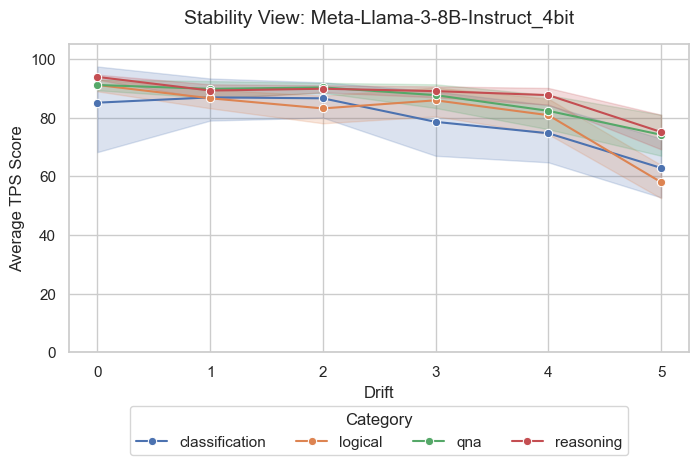

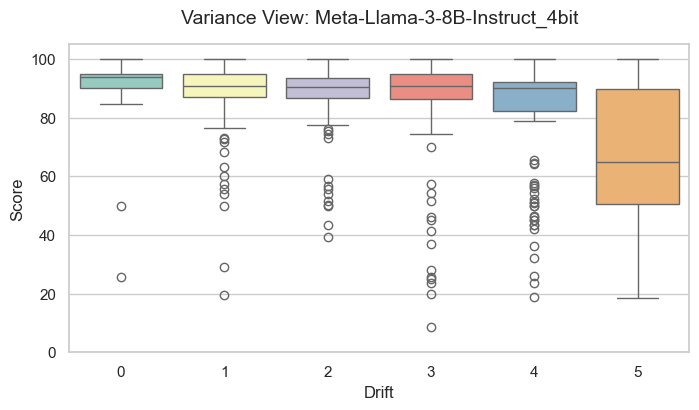

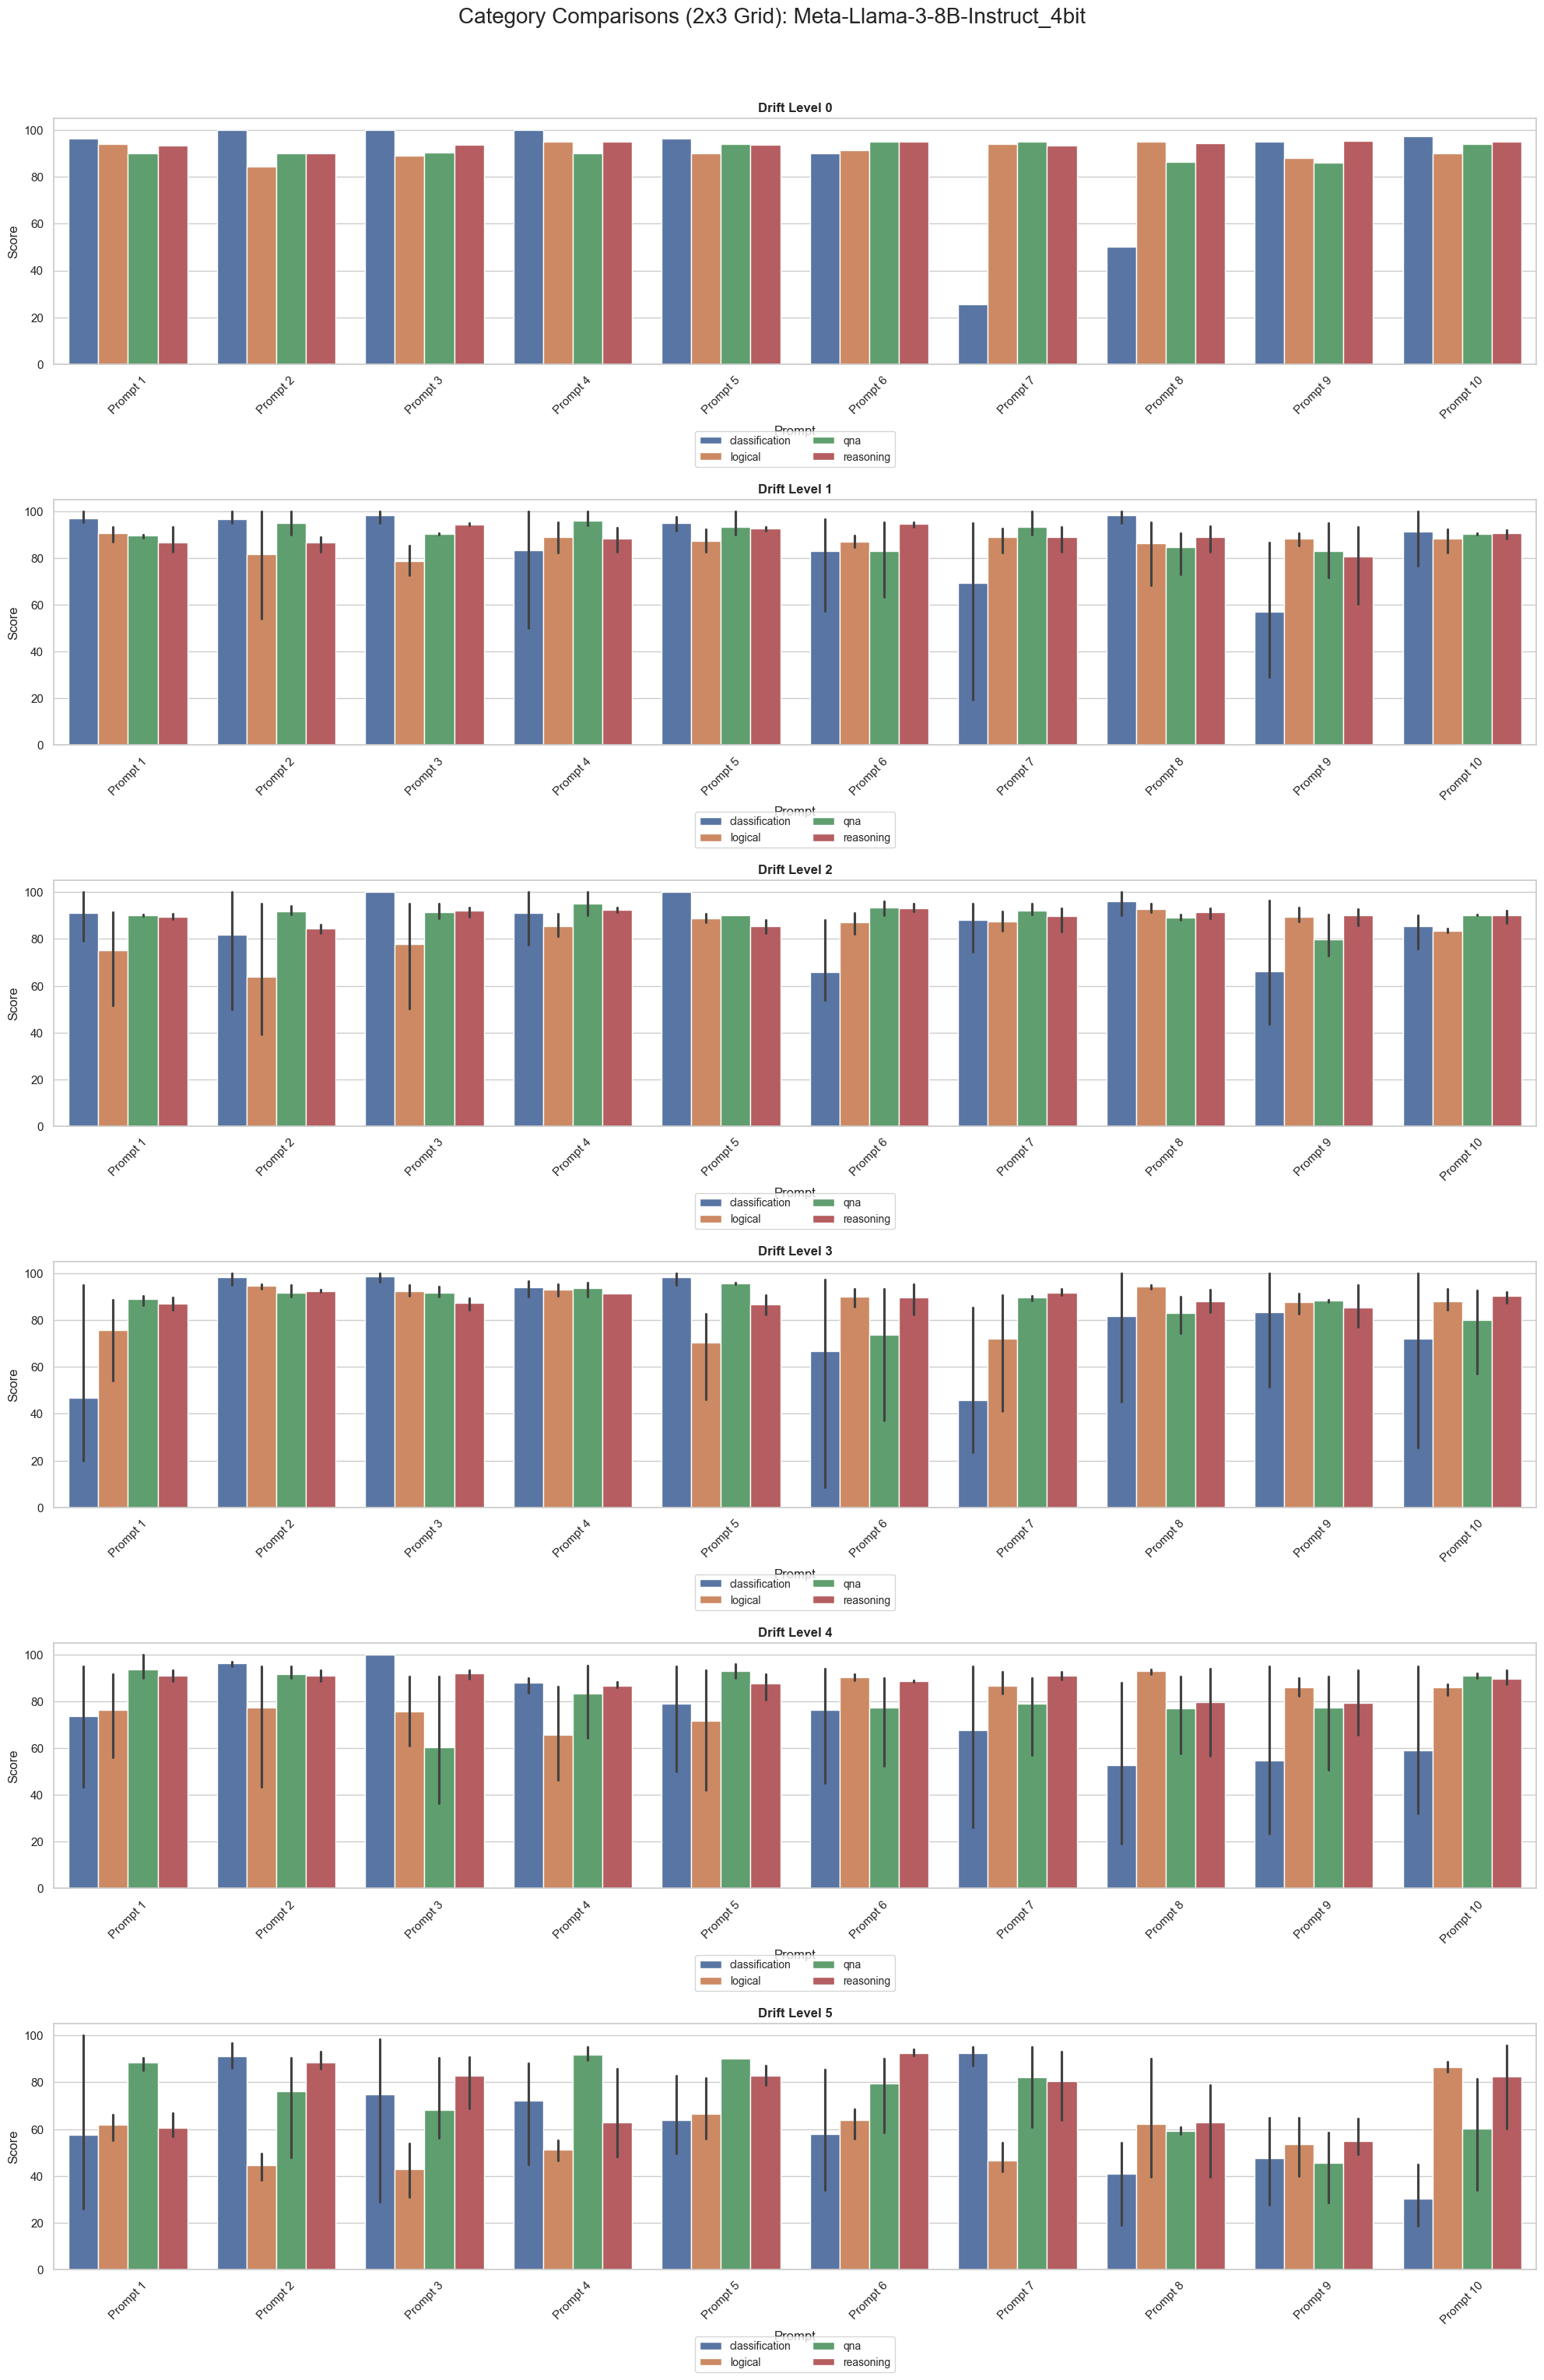

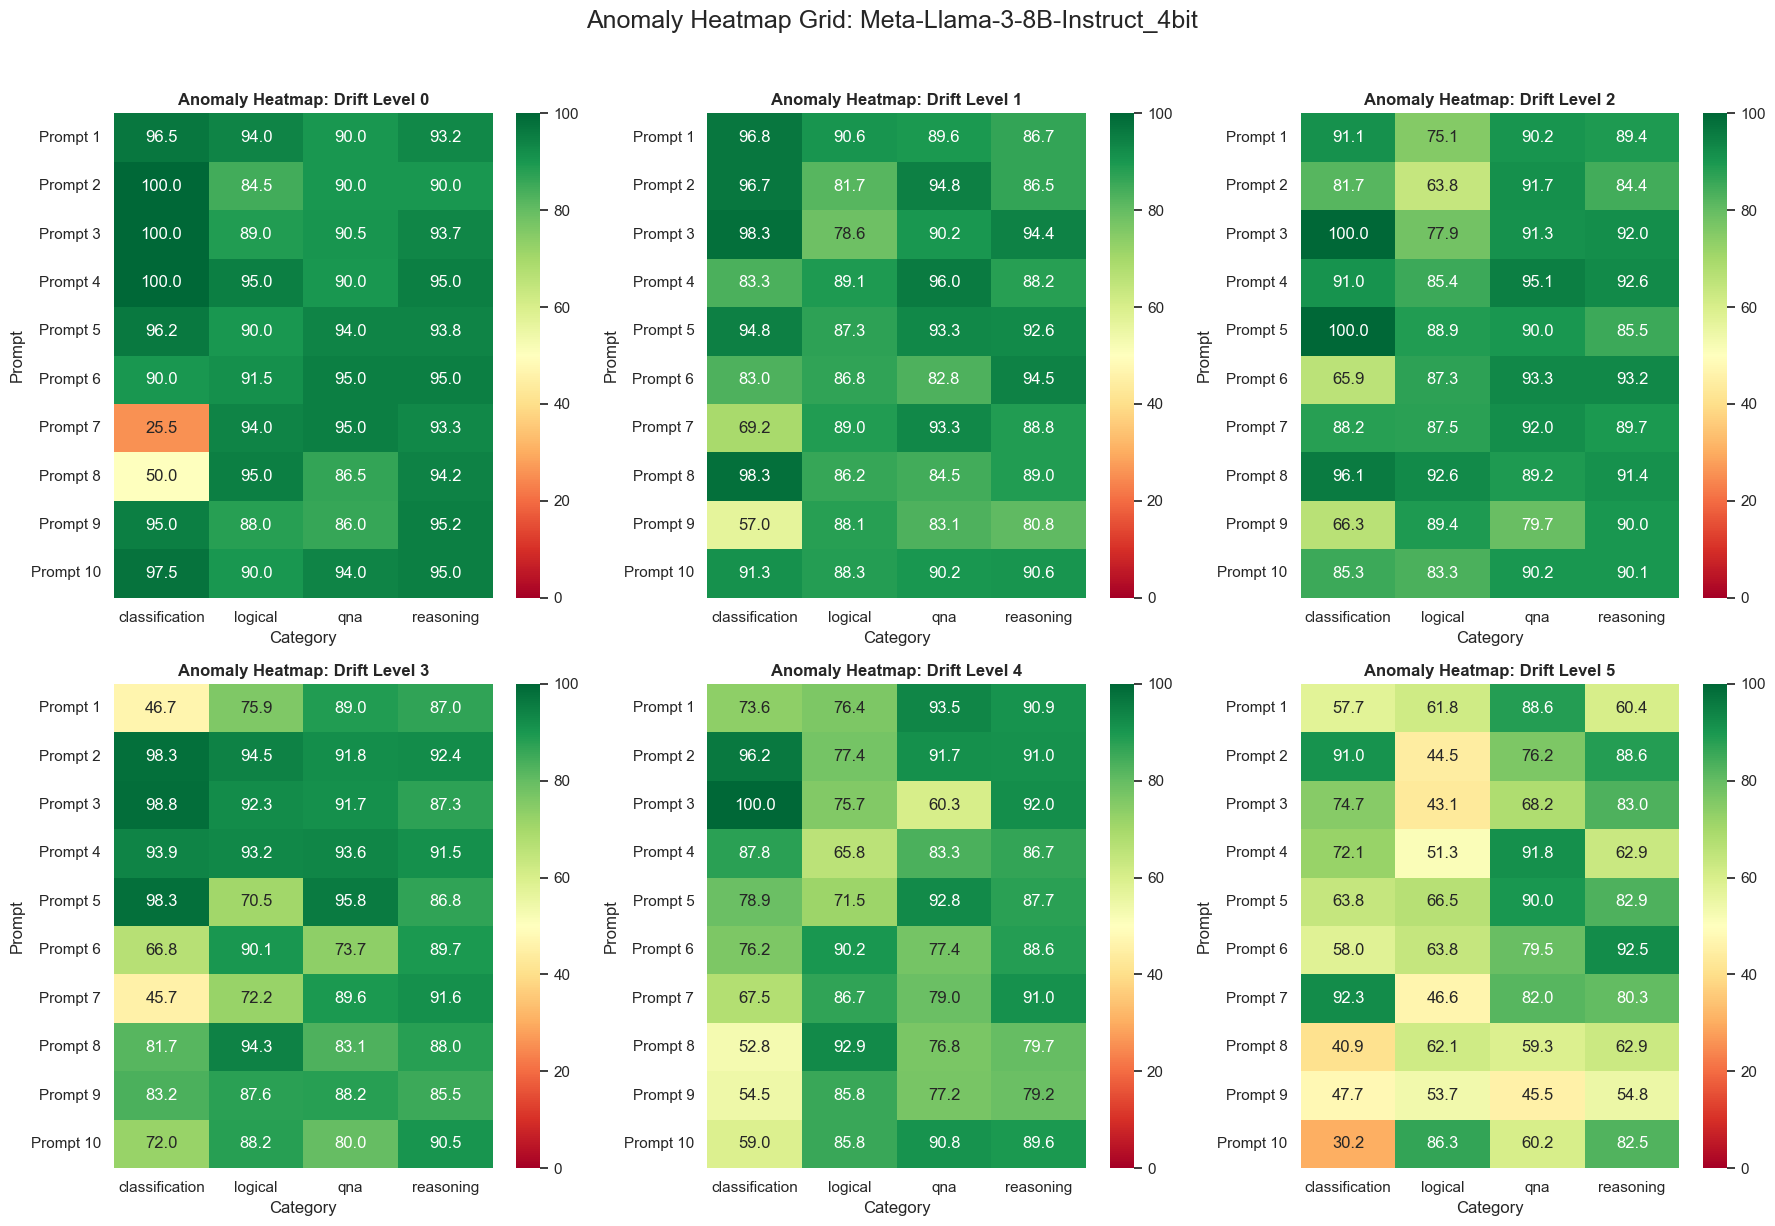


REPORT FOR: Meta-Llama-3-8B-Instruct_8bit


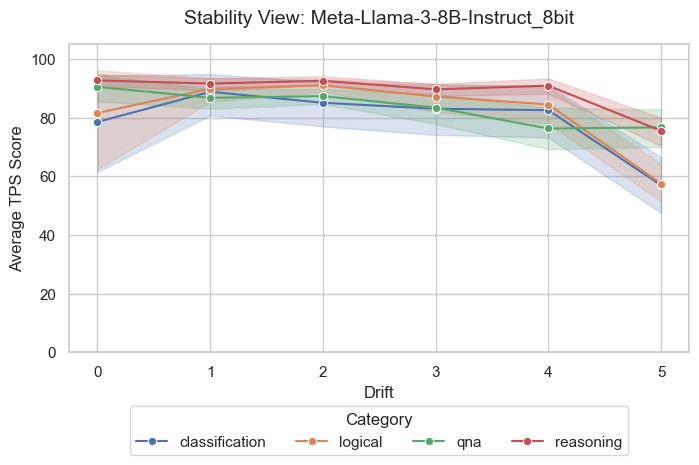

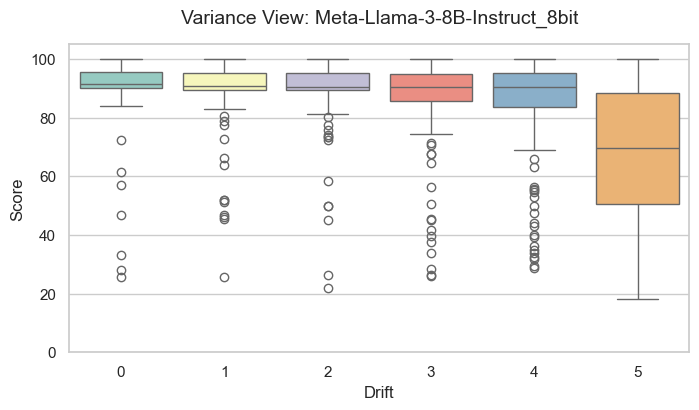

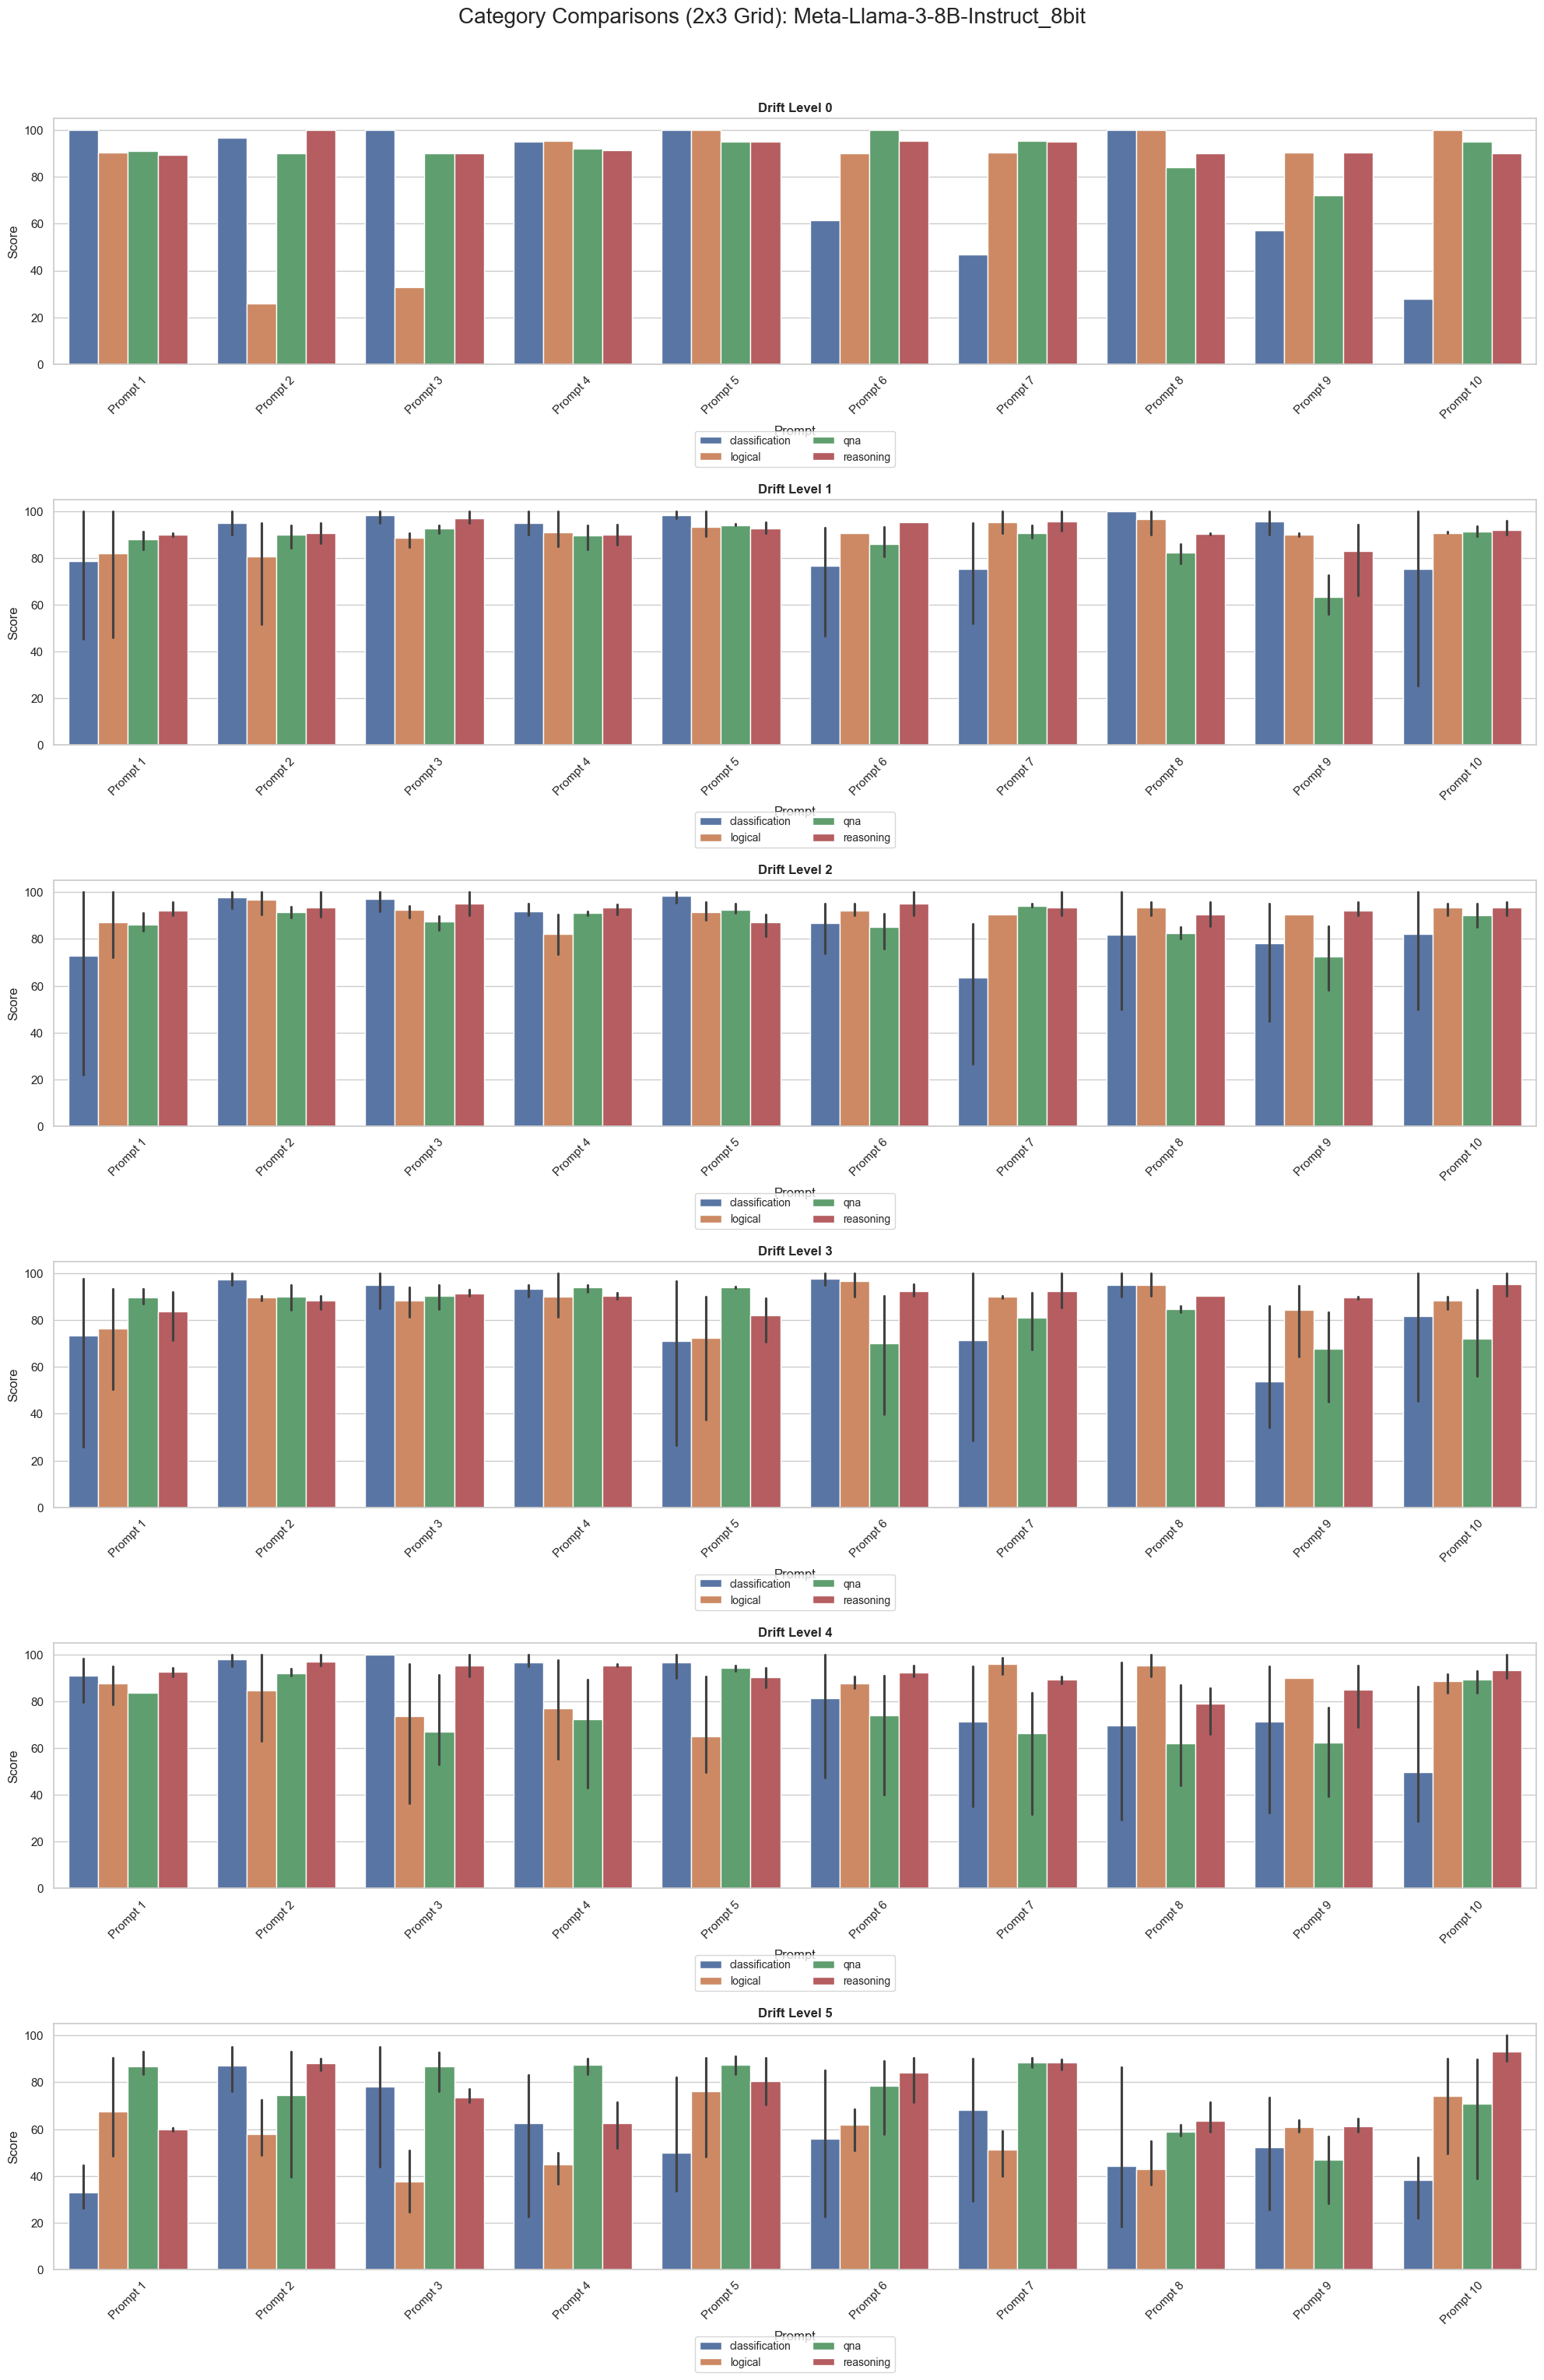

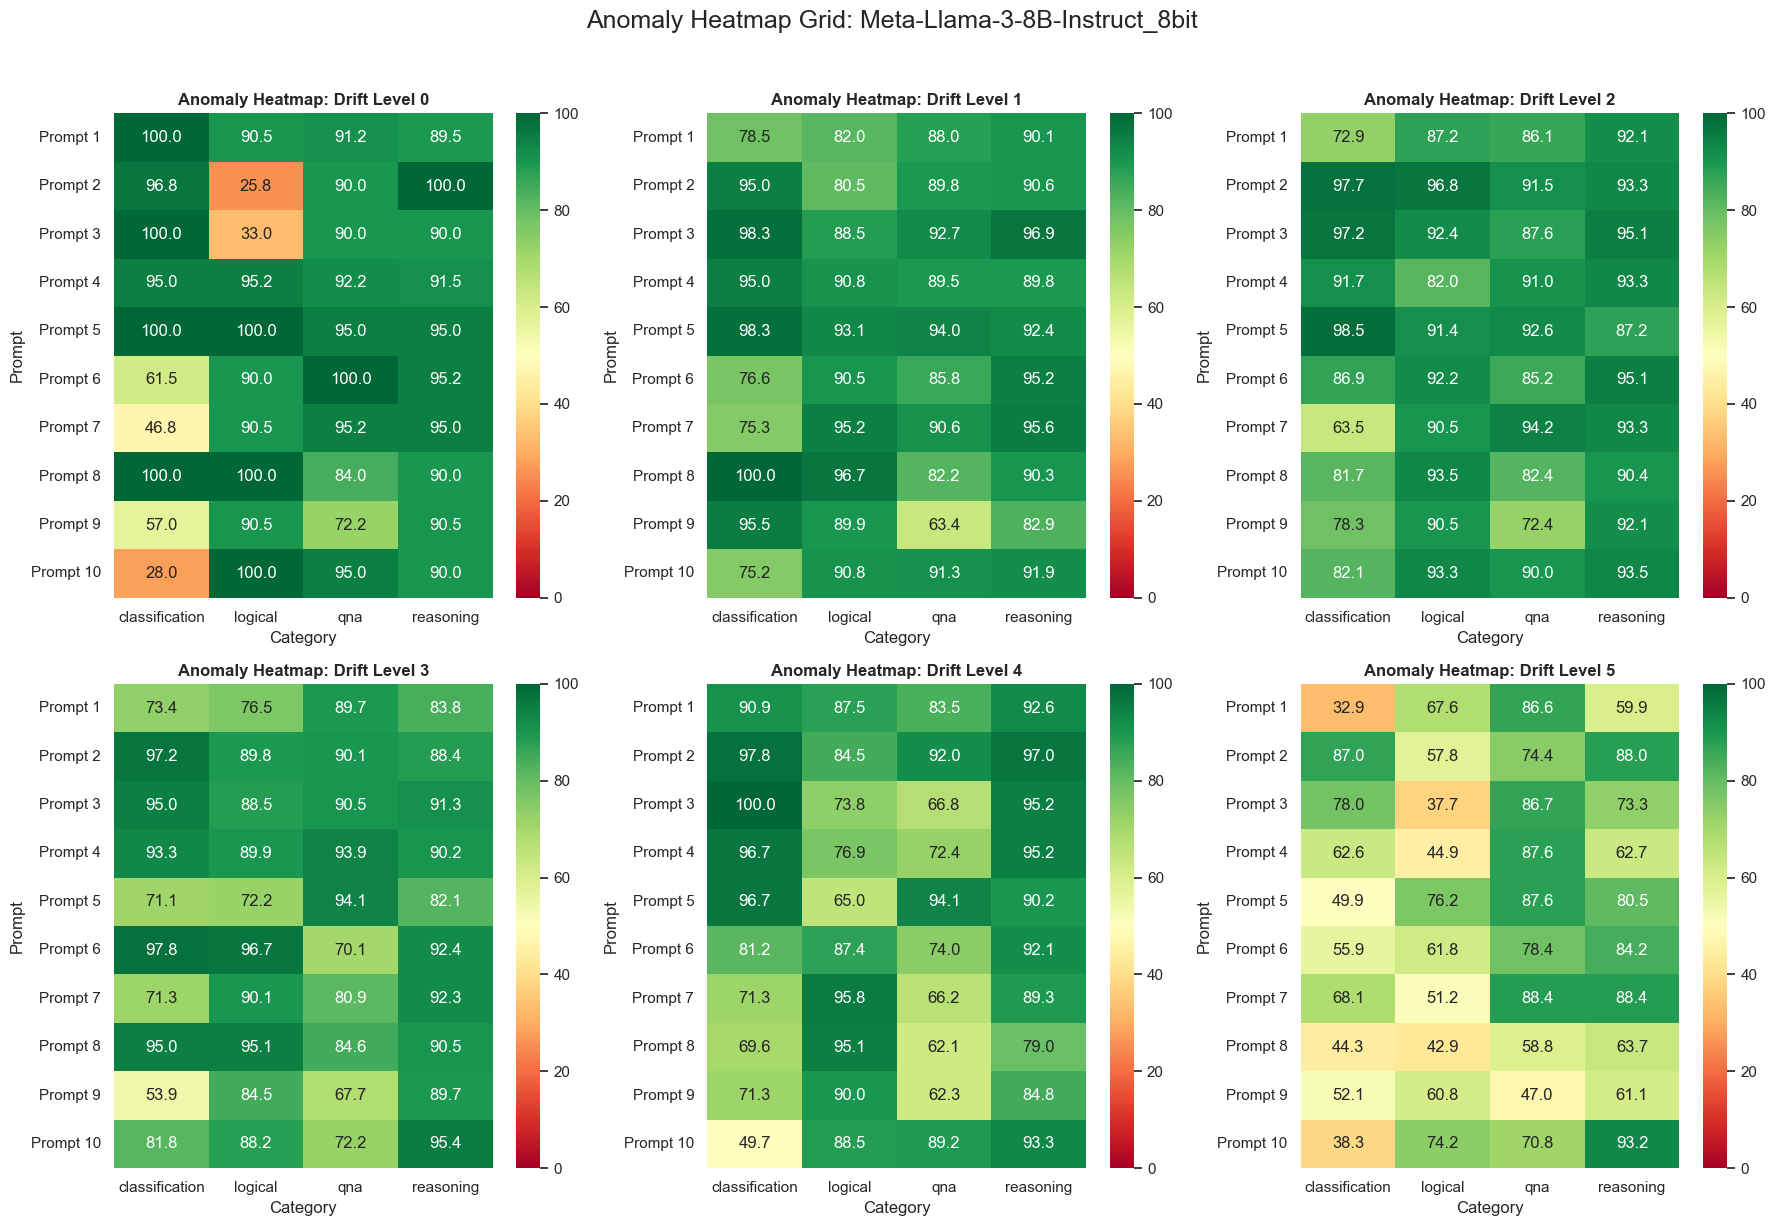


REPORT FOR: Meta-Llama-3-8B-Instruct_fp16


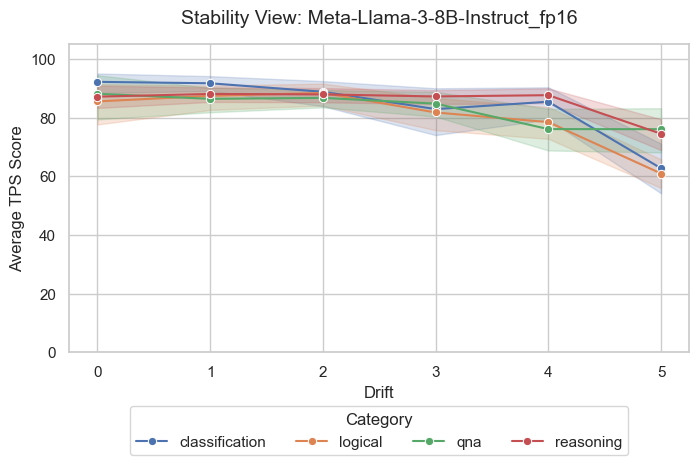

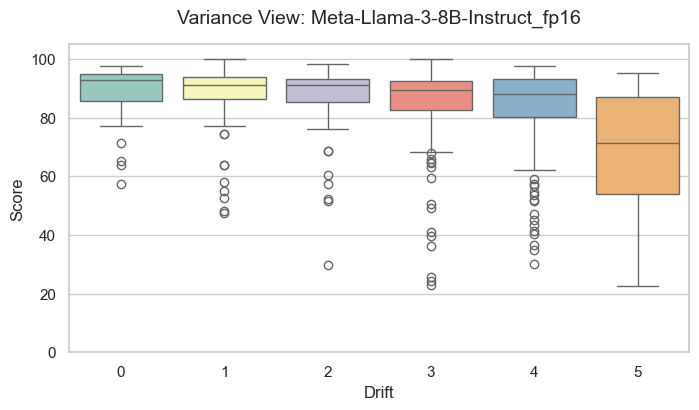

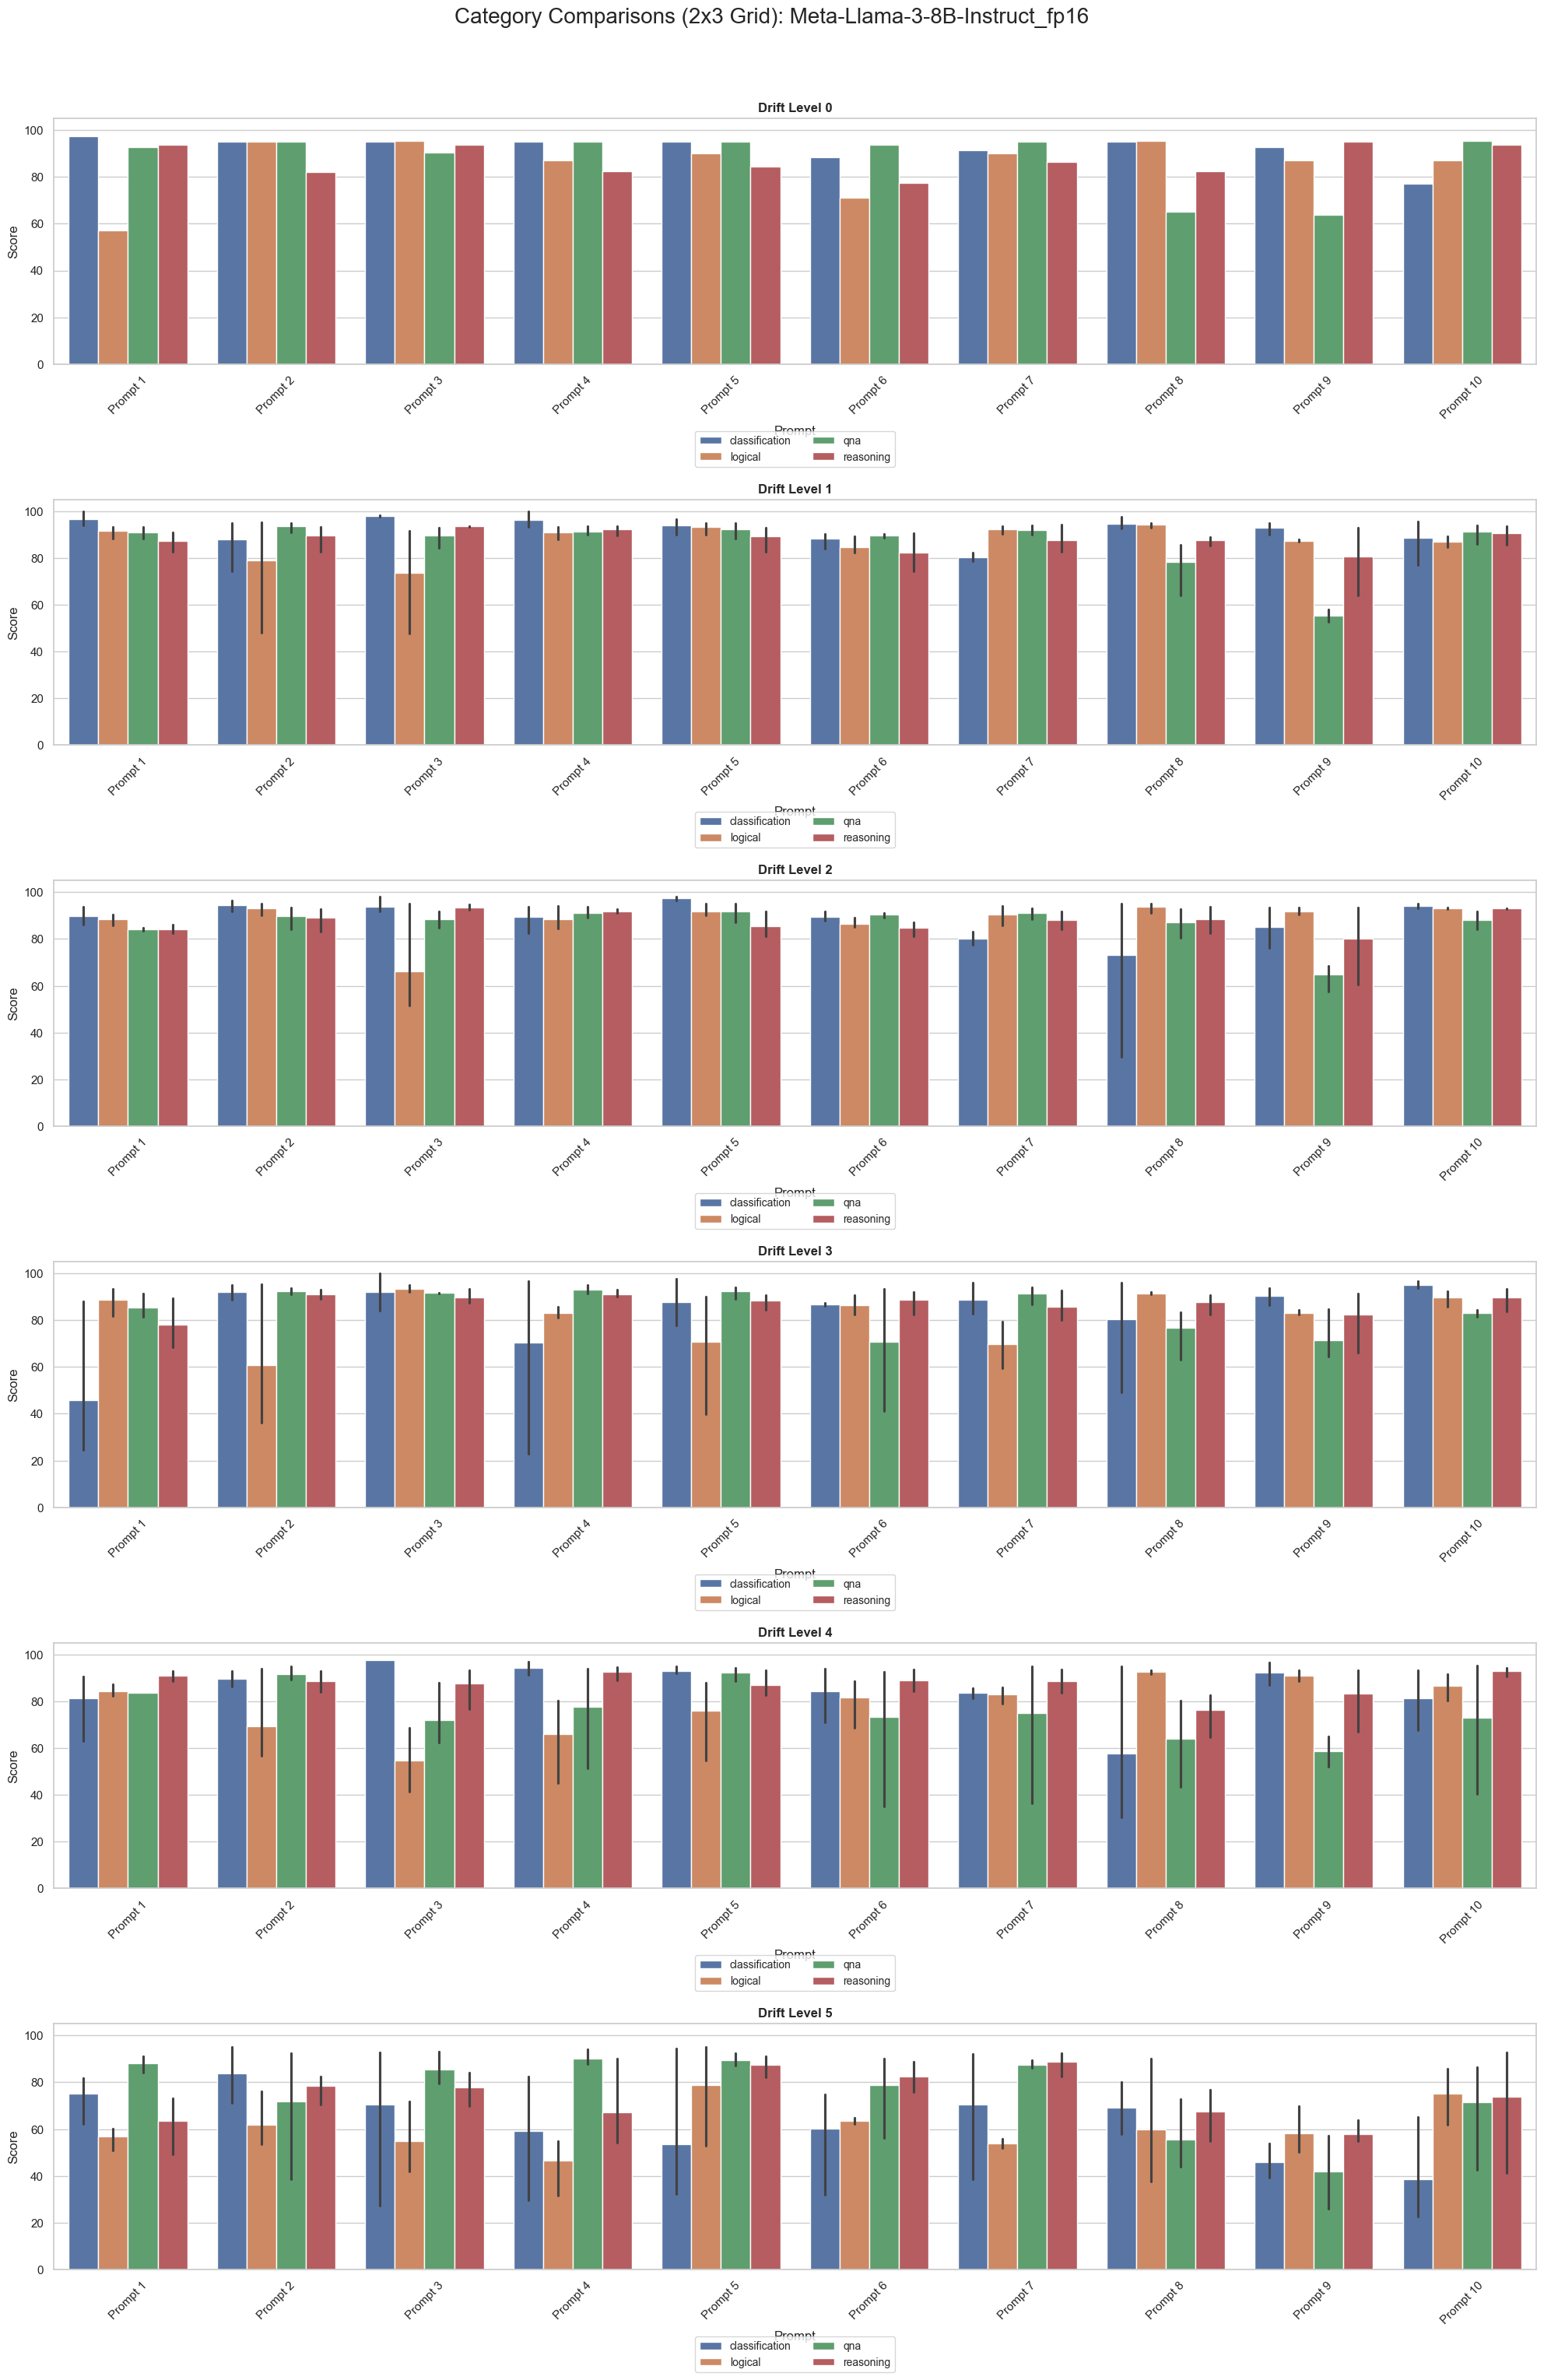

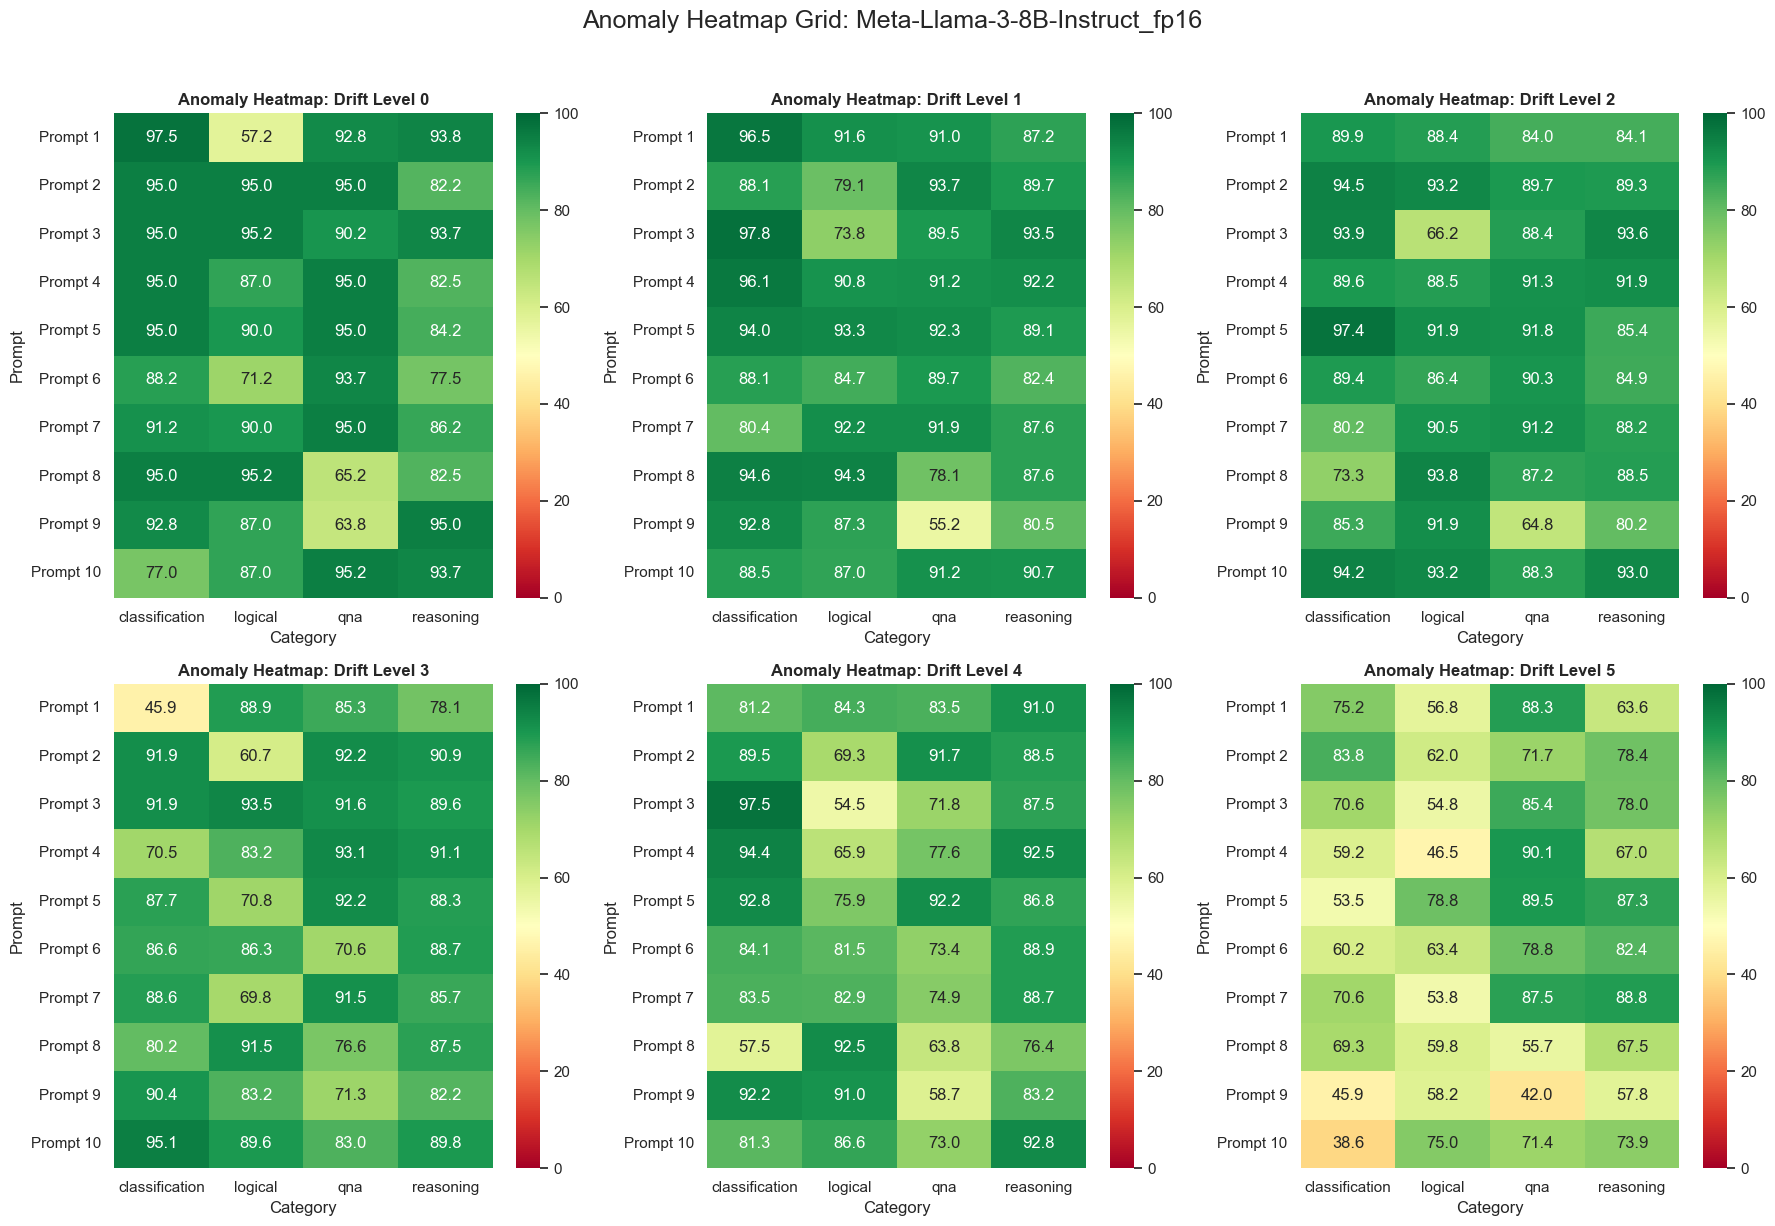


REPORT FOR: Phi-3-mini-4k-instruct_4bit


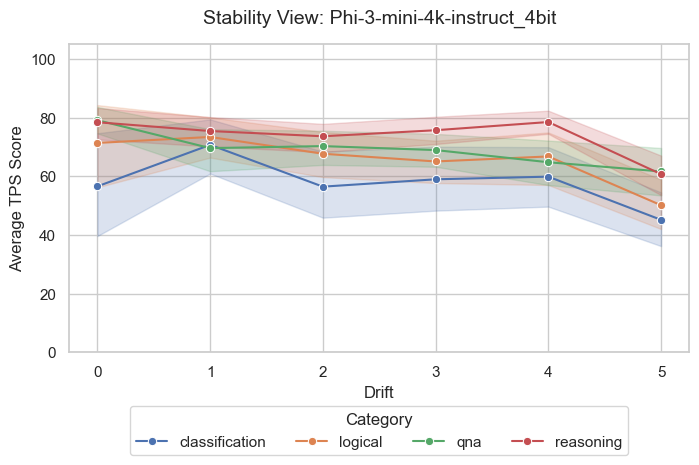

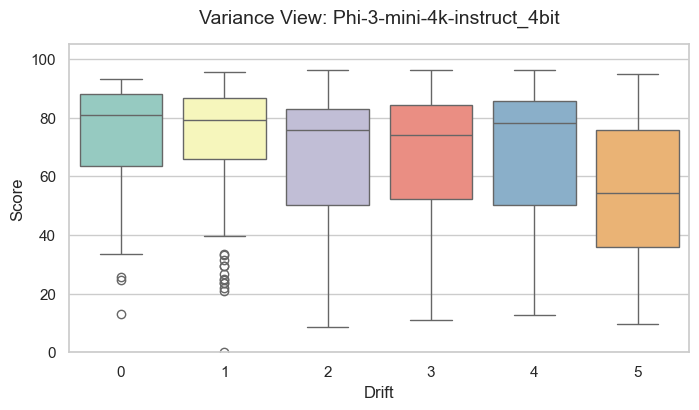

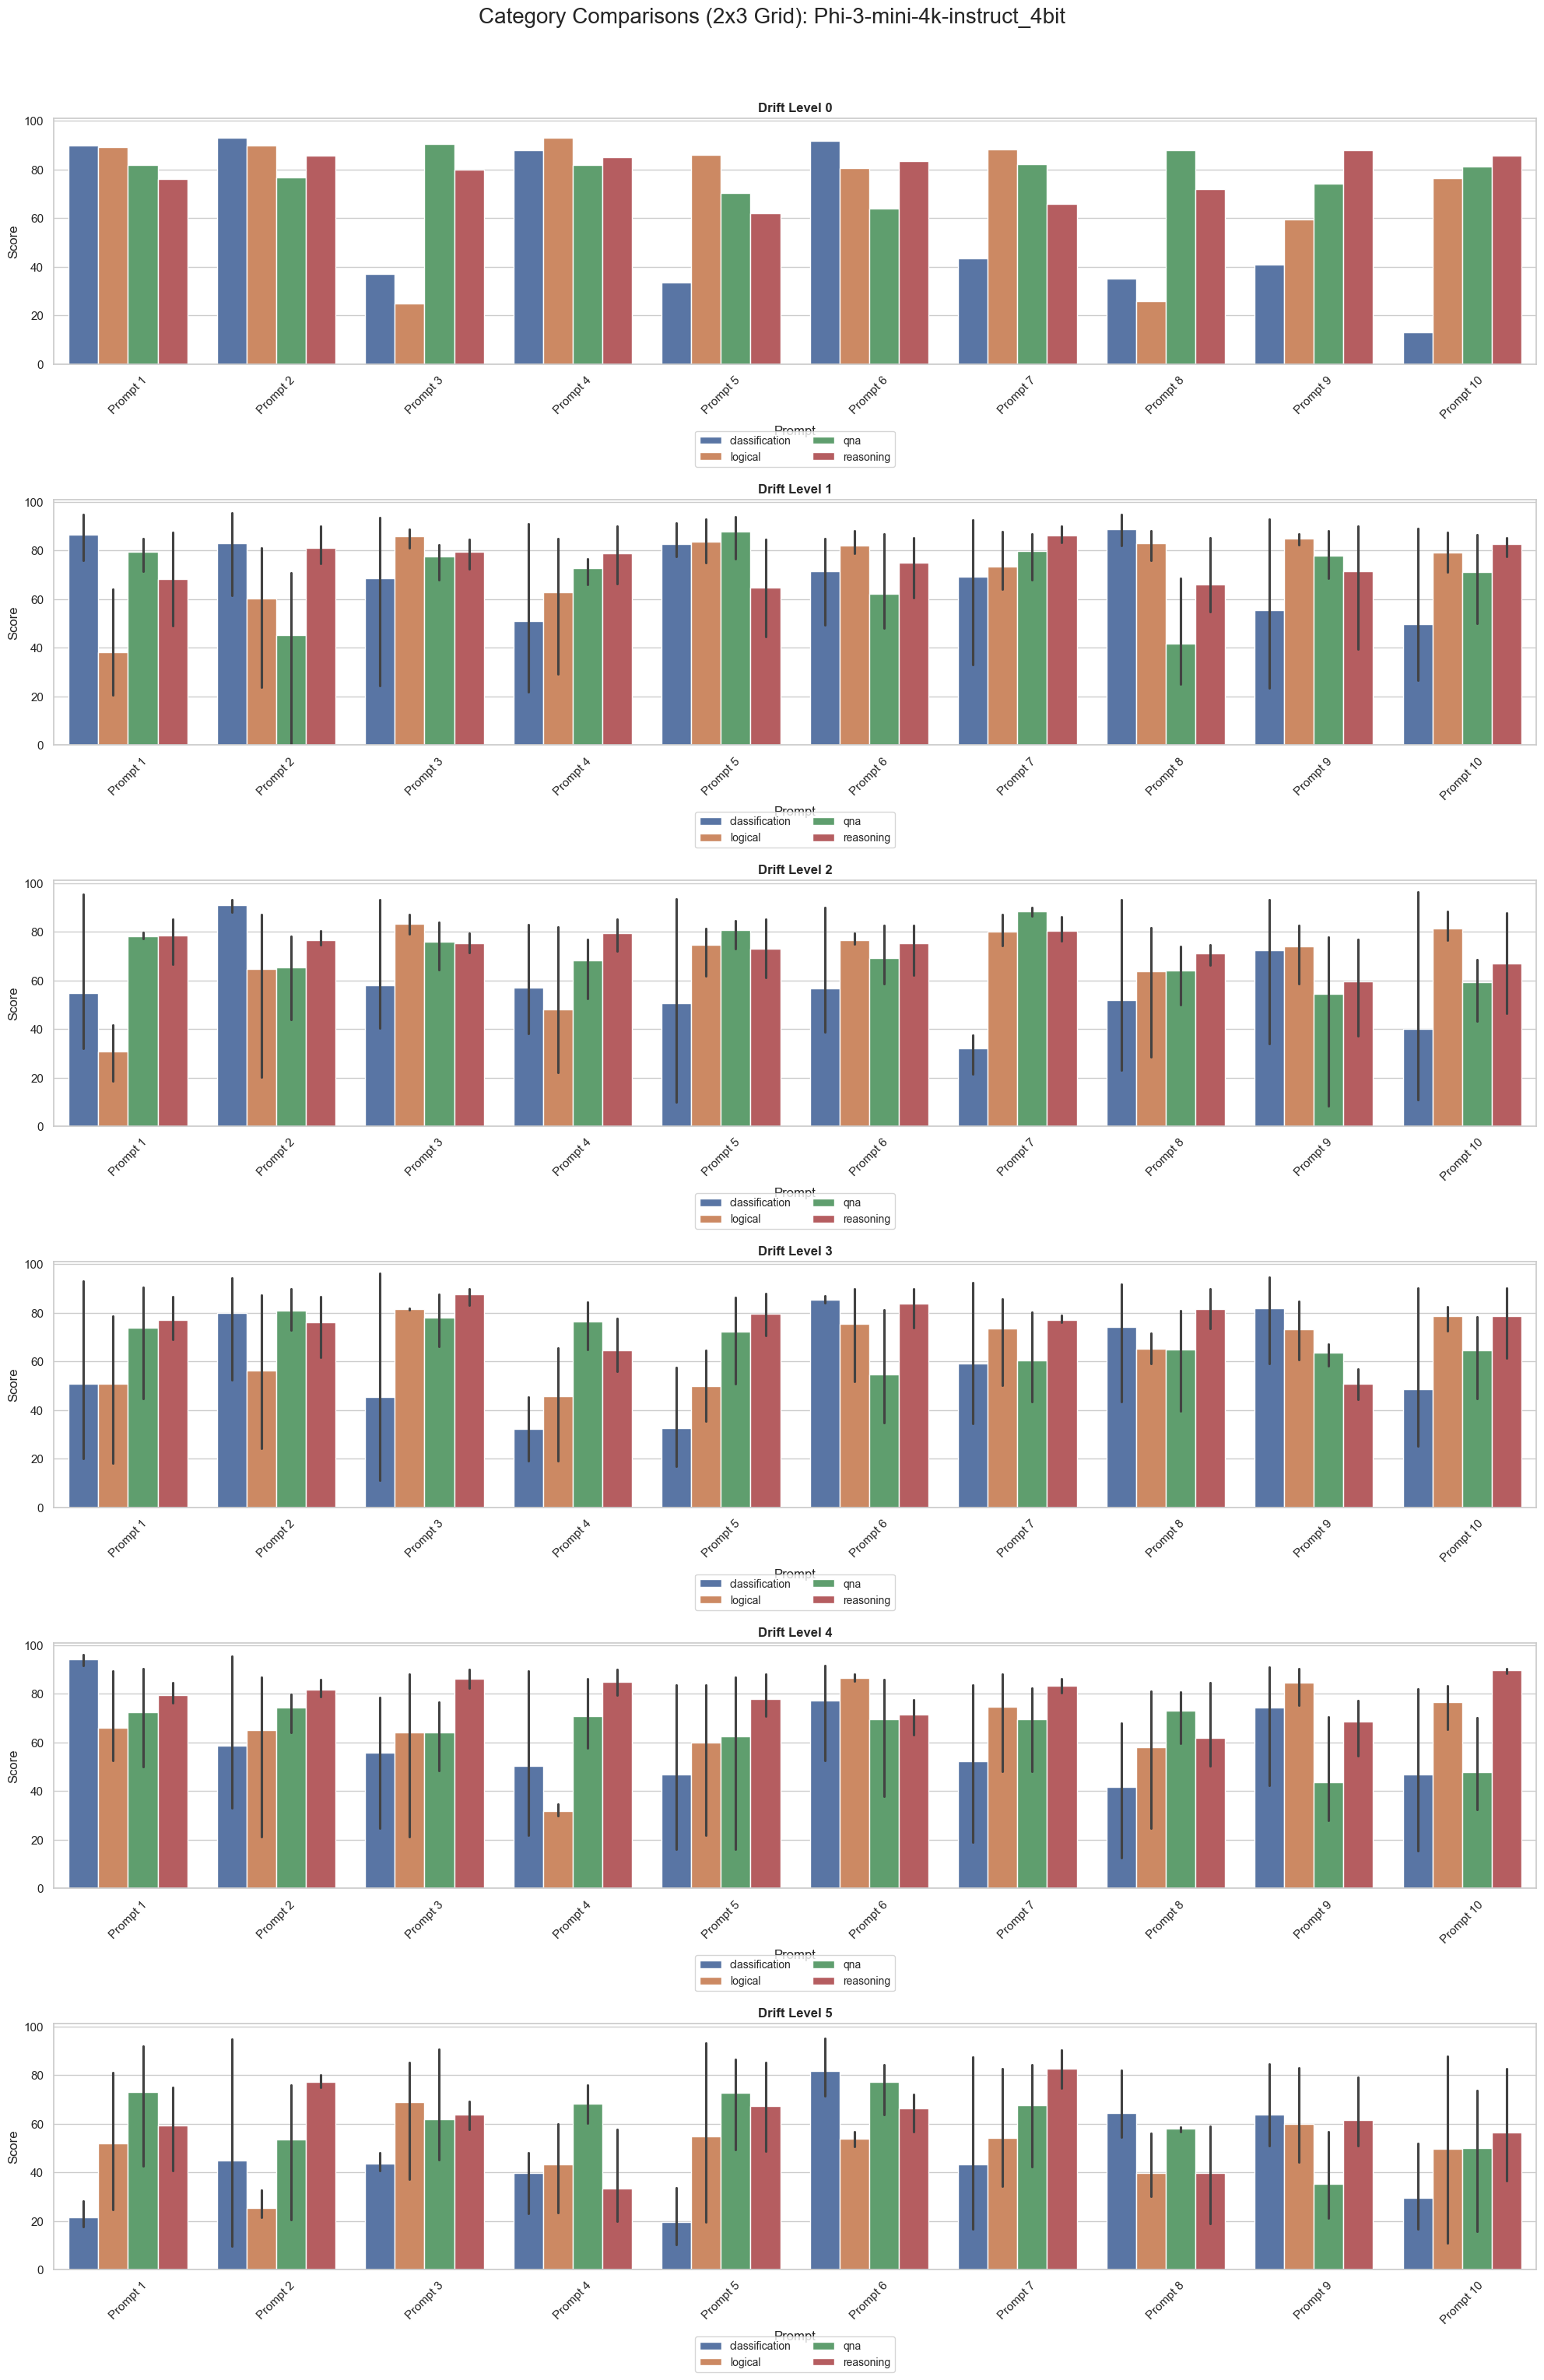

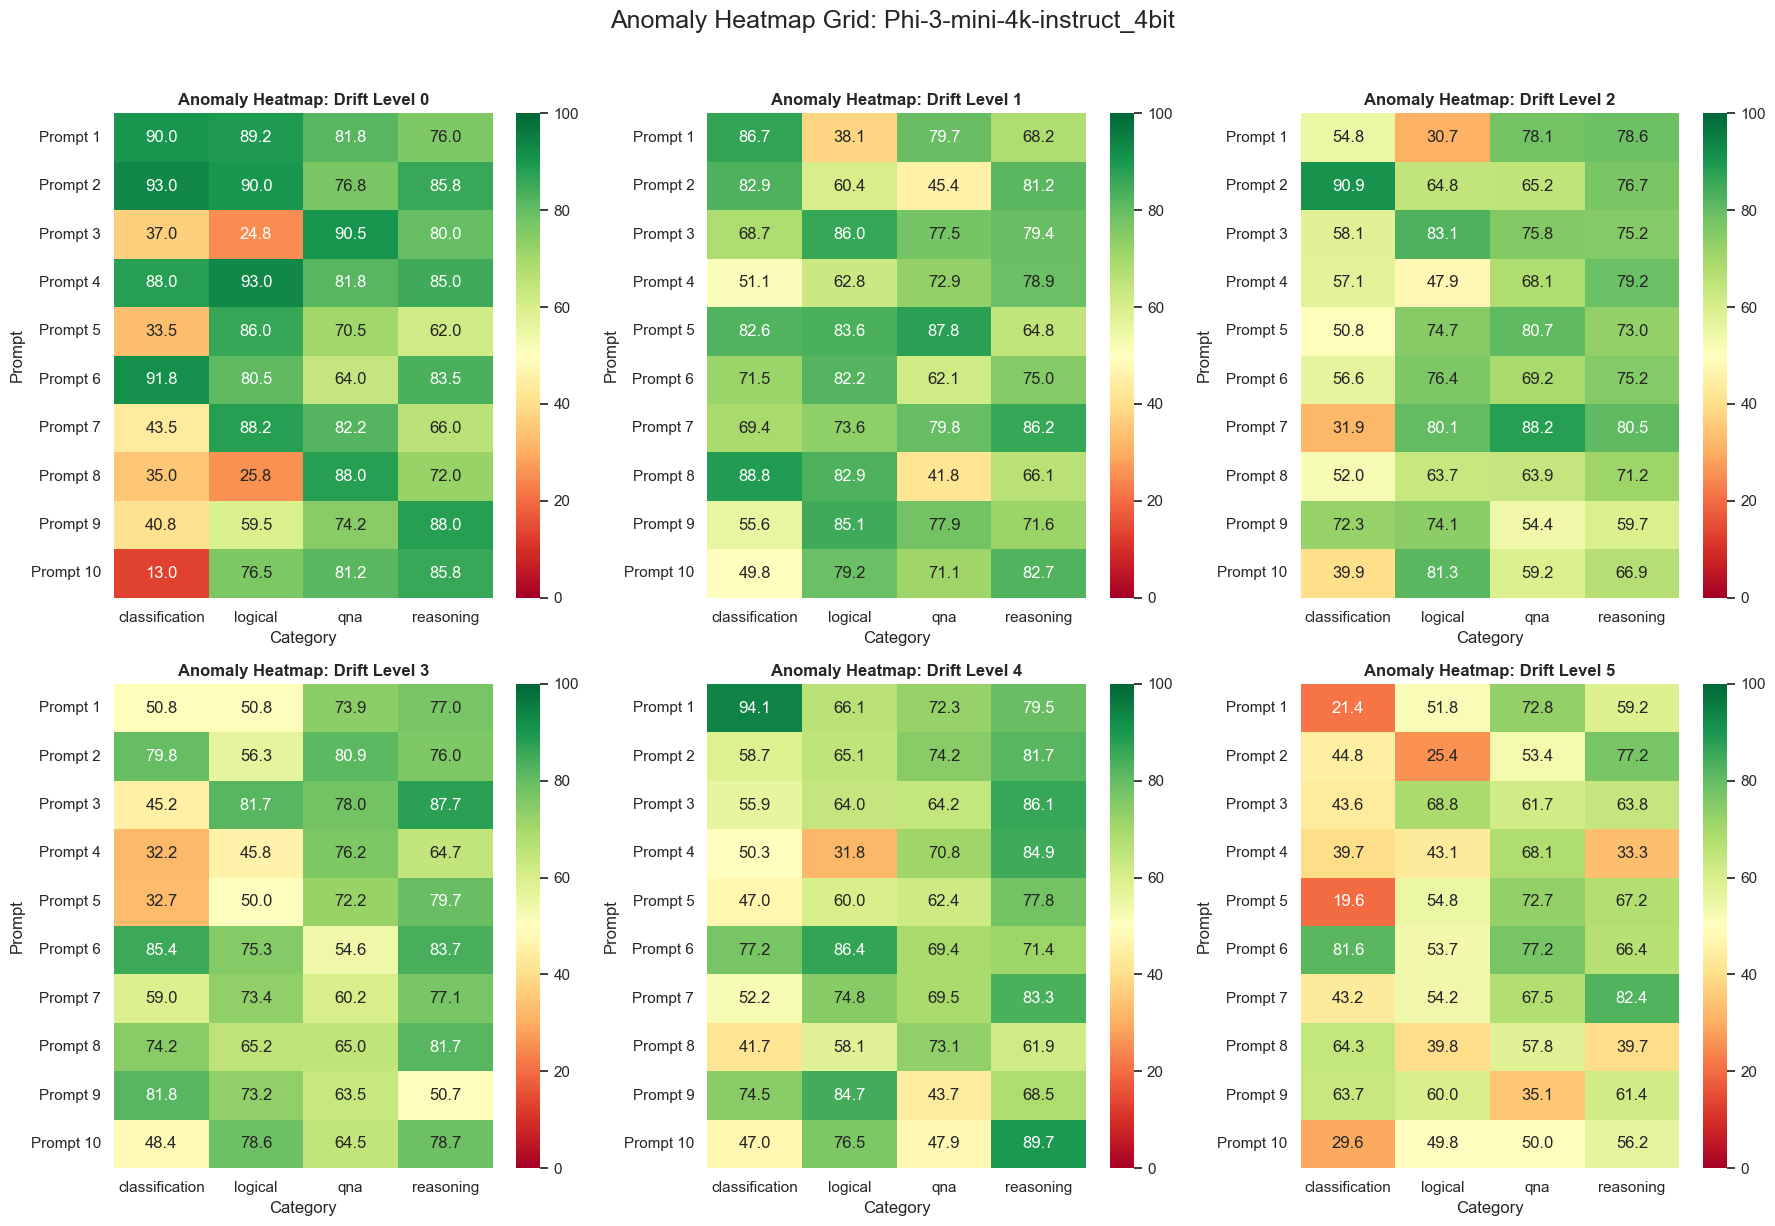


REPORT FOR: Phi-3-mini-4k-instruct_8bit


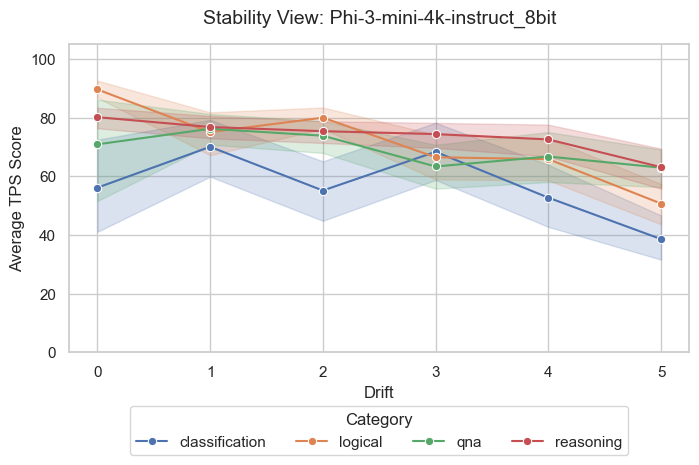

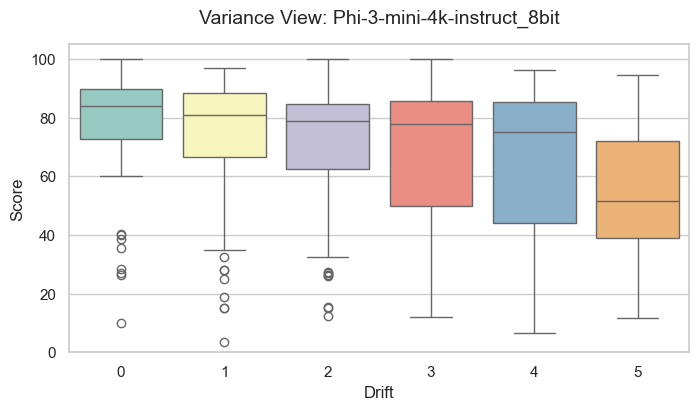

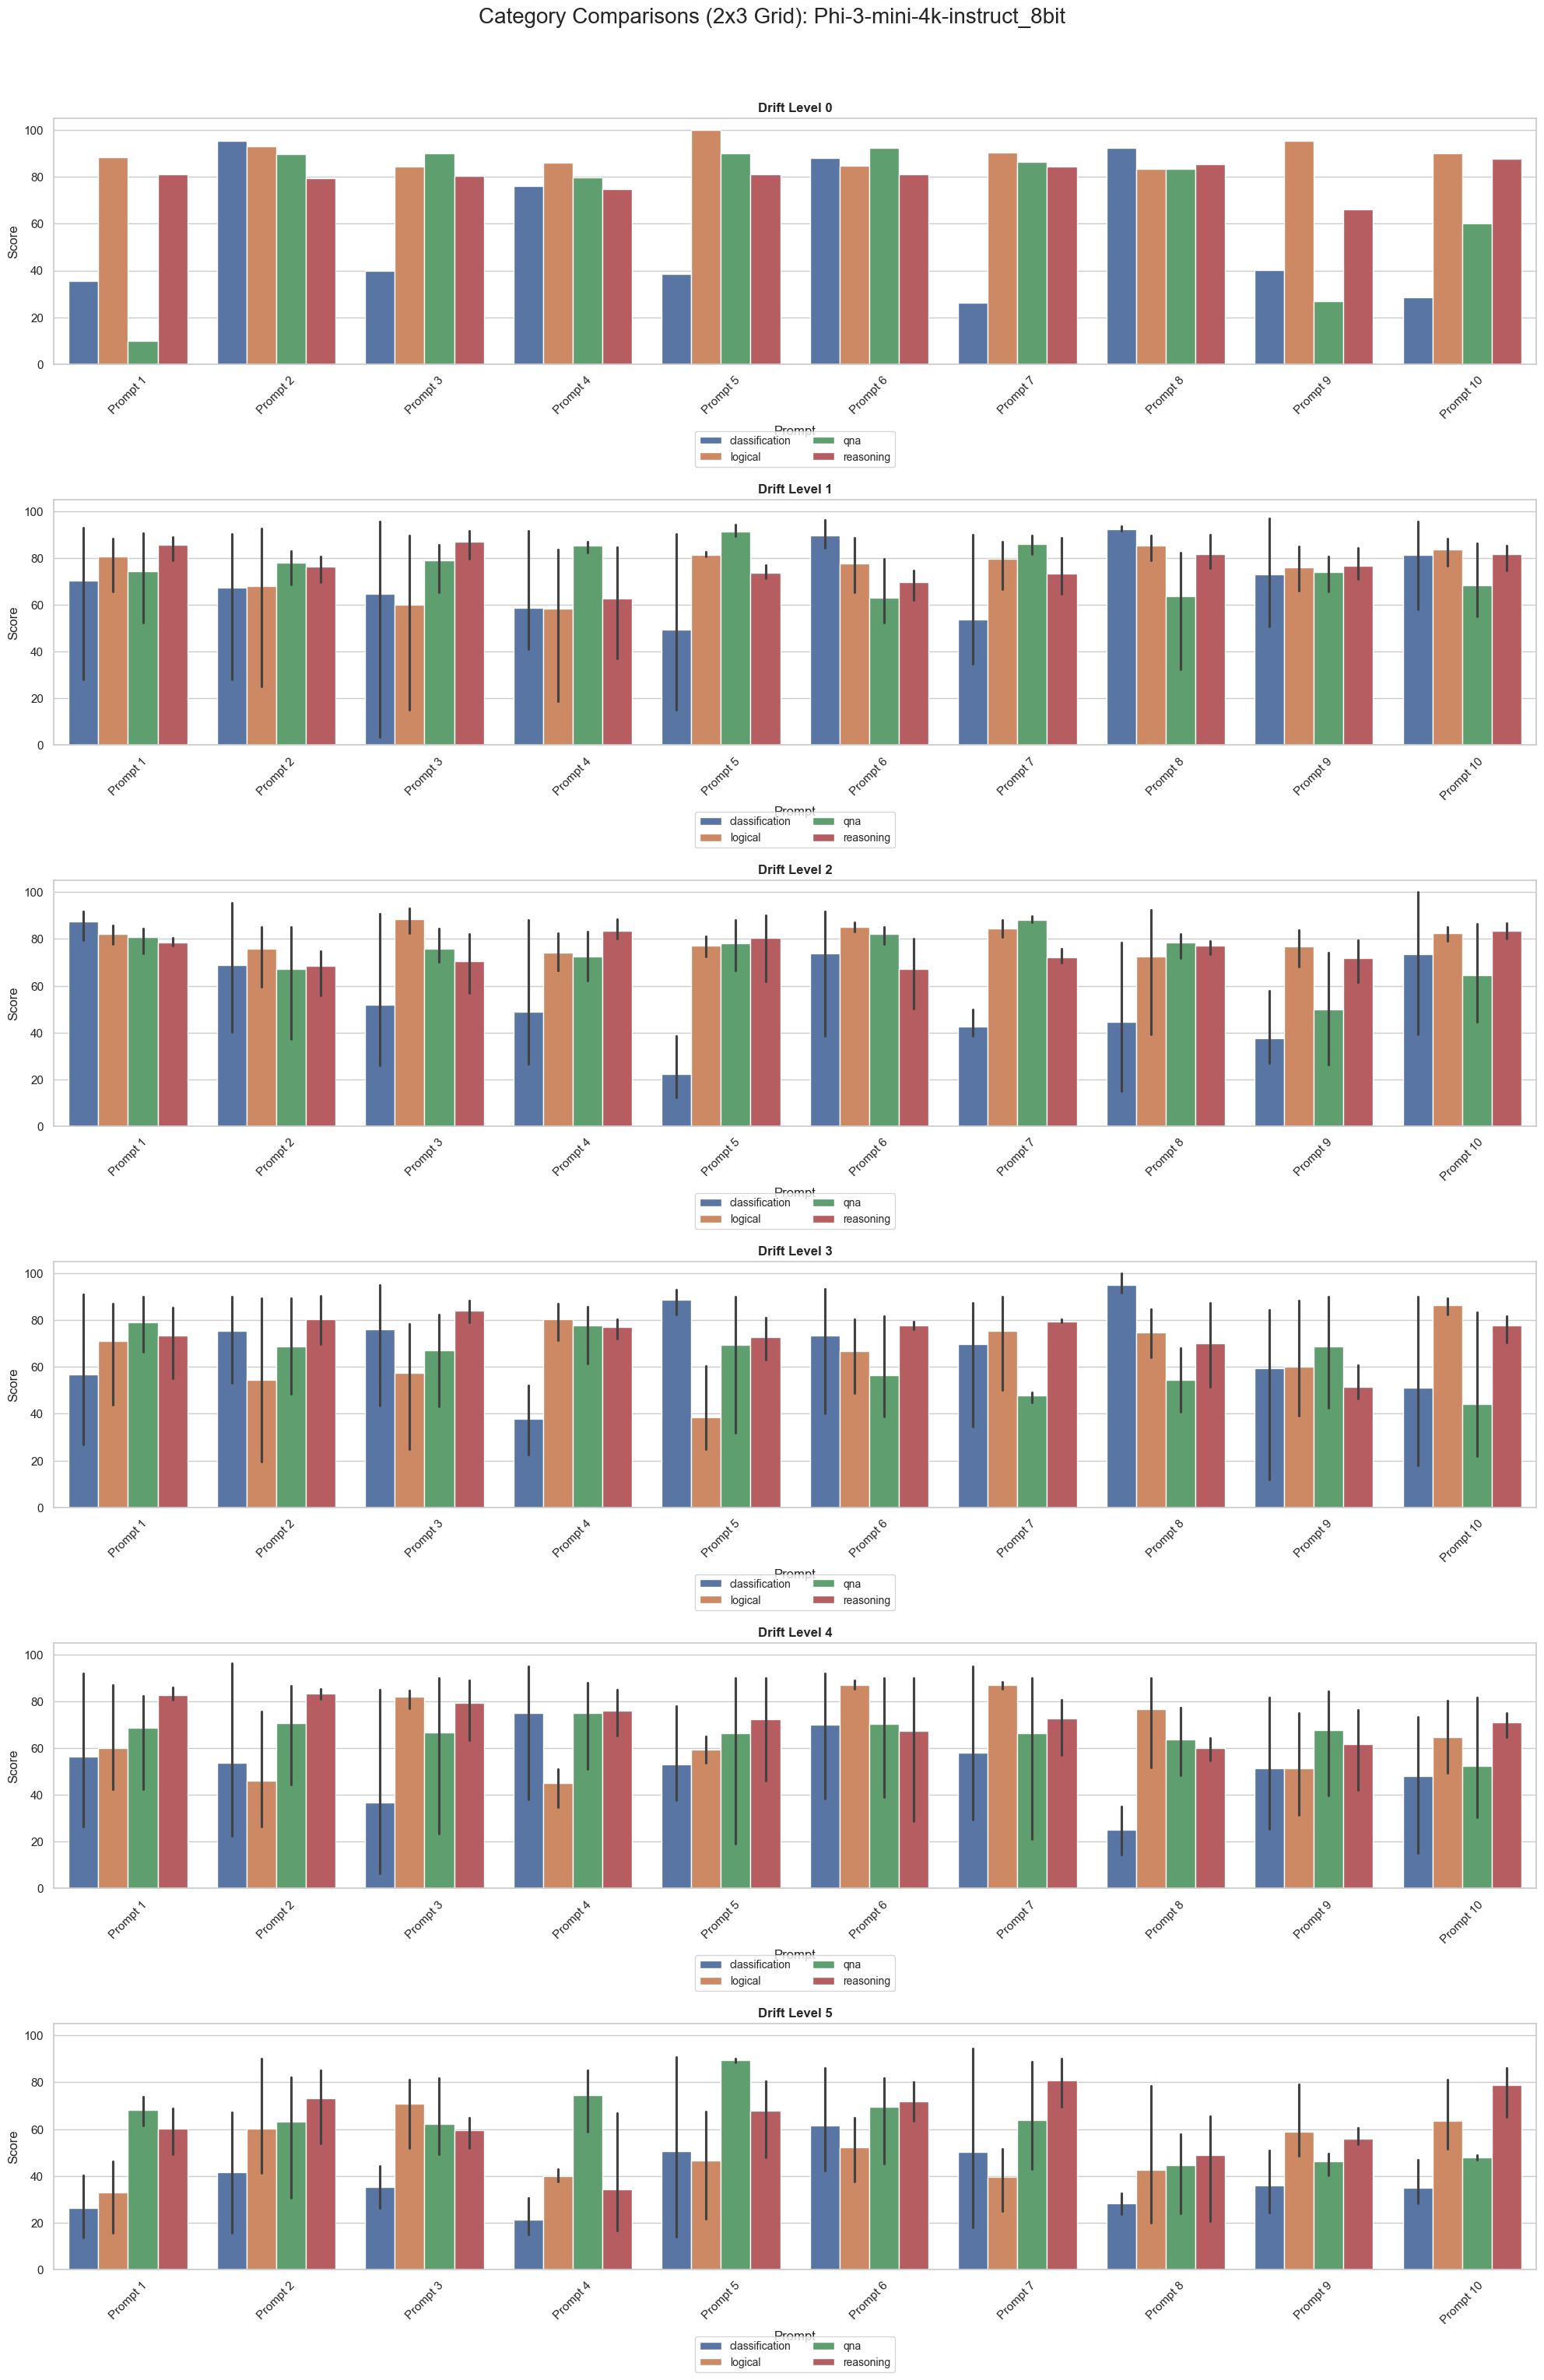

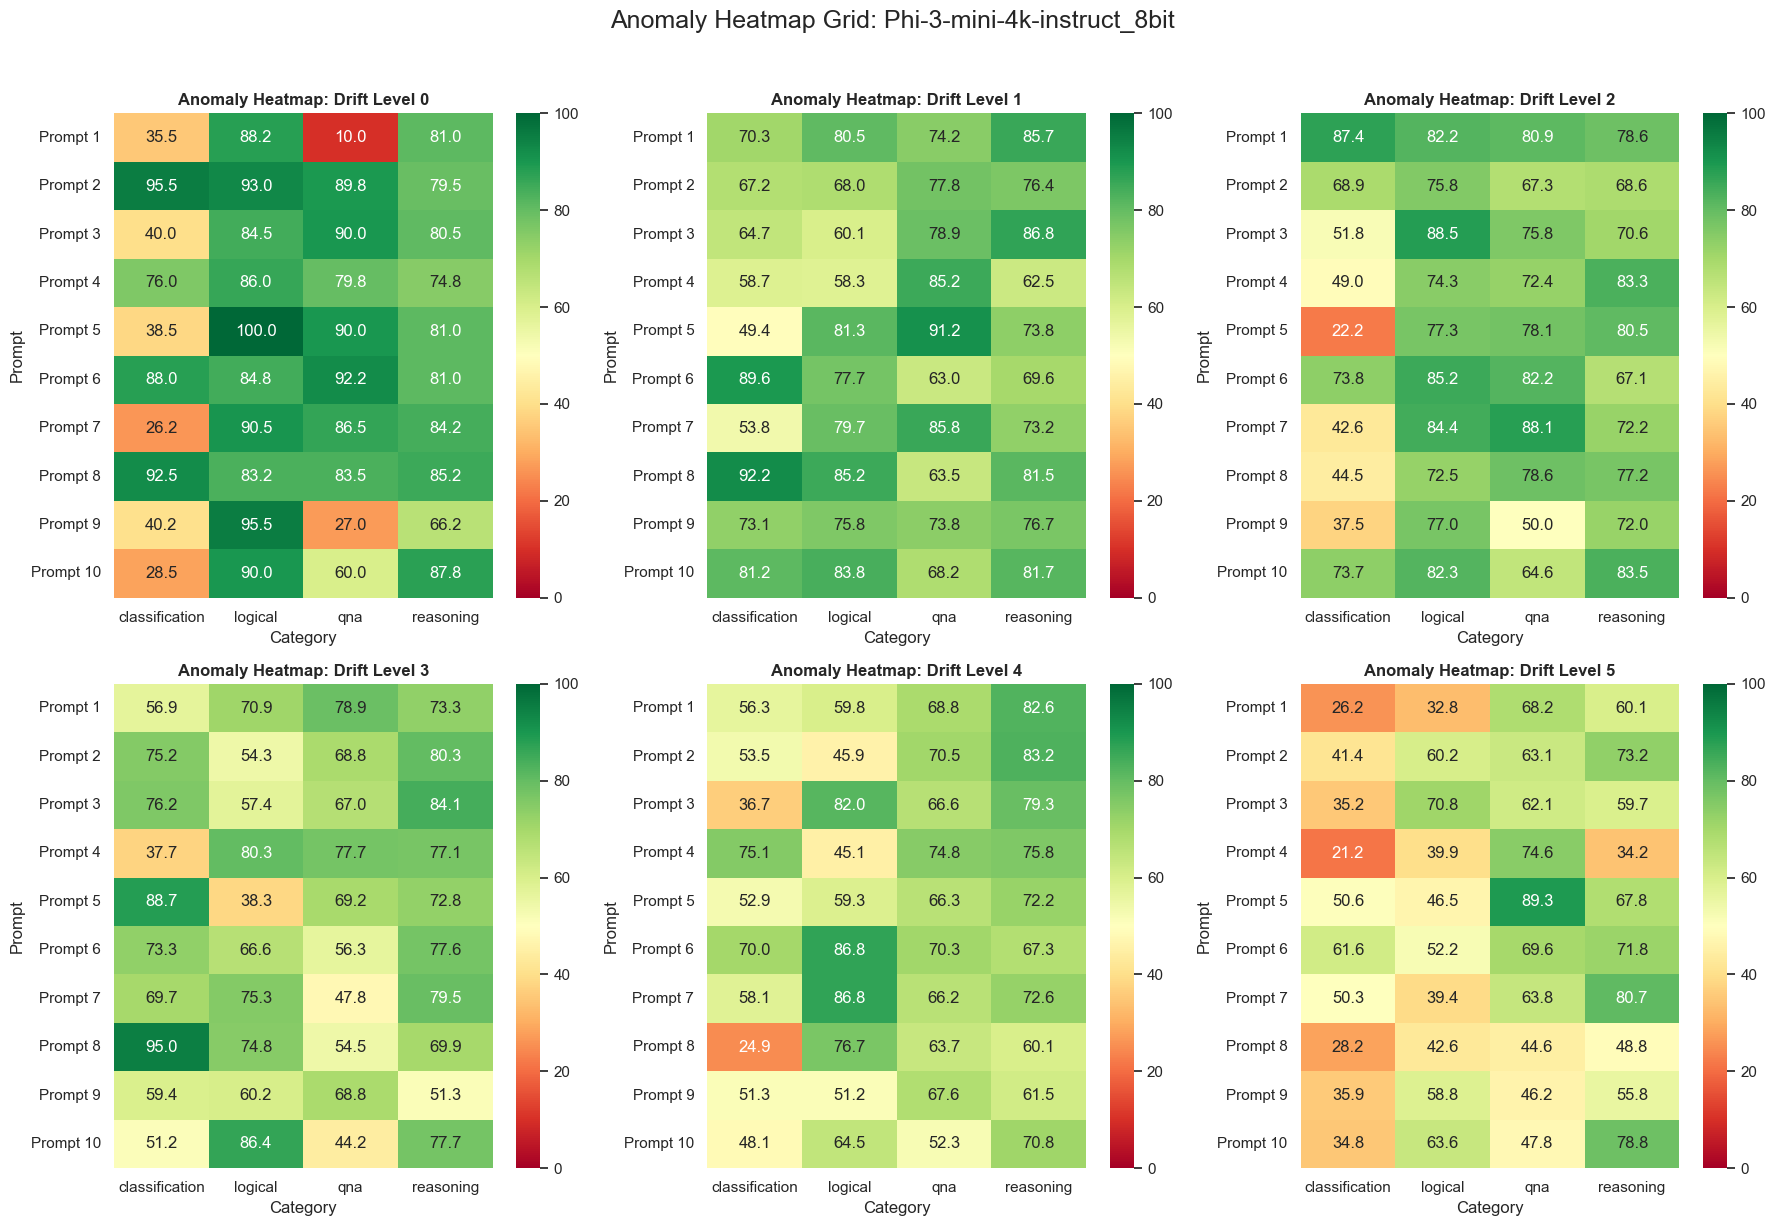


REPORT FOR: Phi-3-mini-4k-instruct_fp16


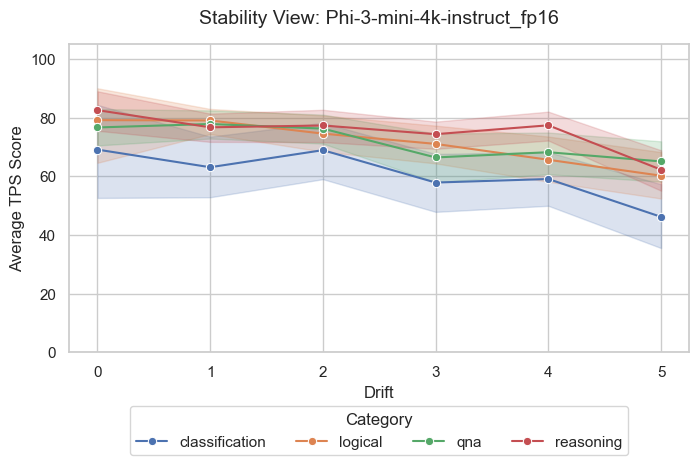

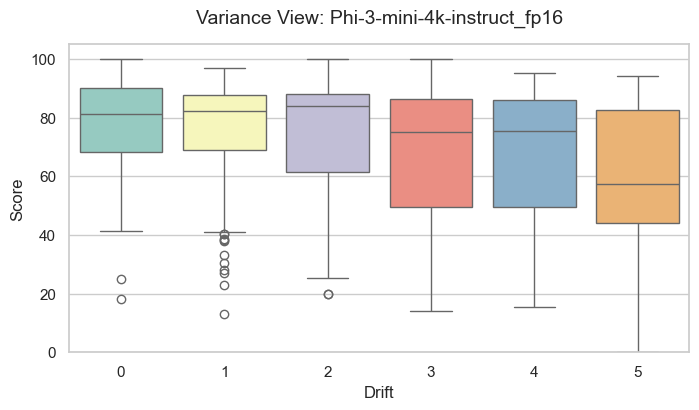

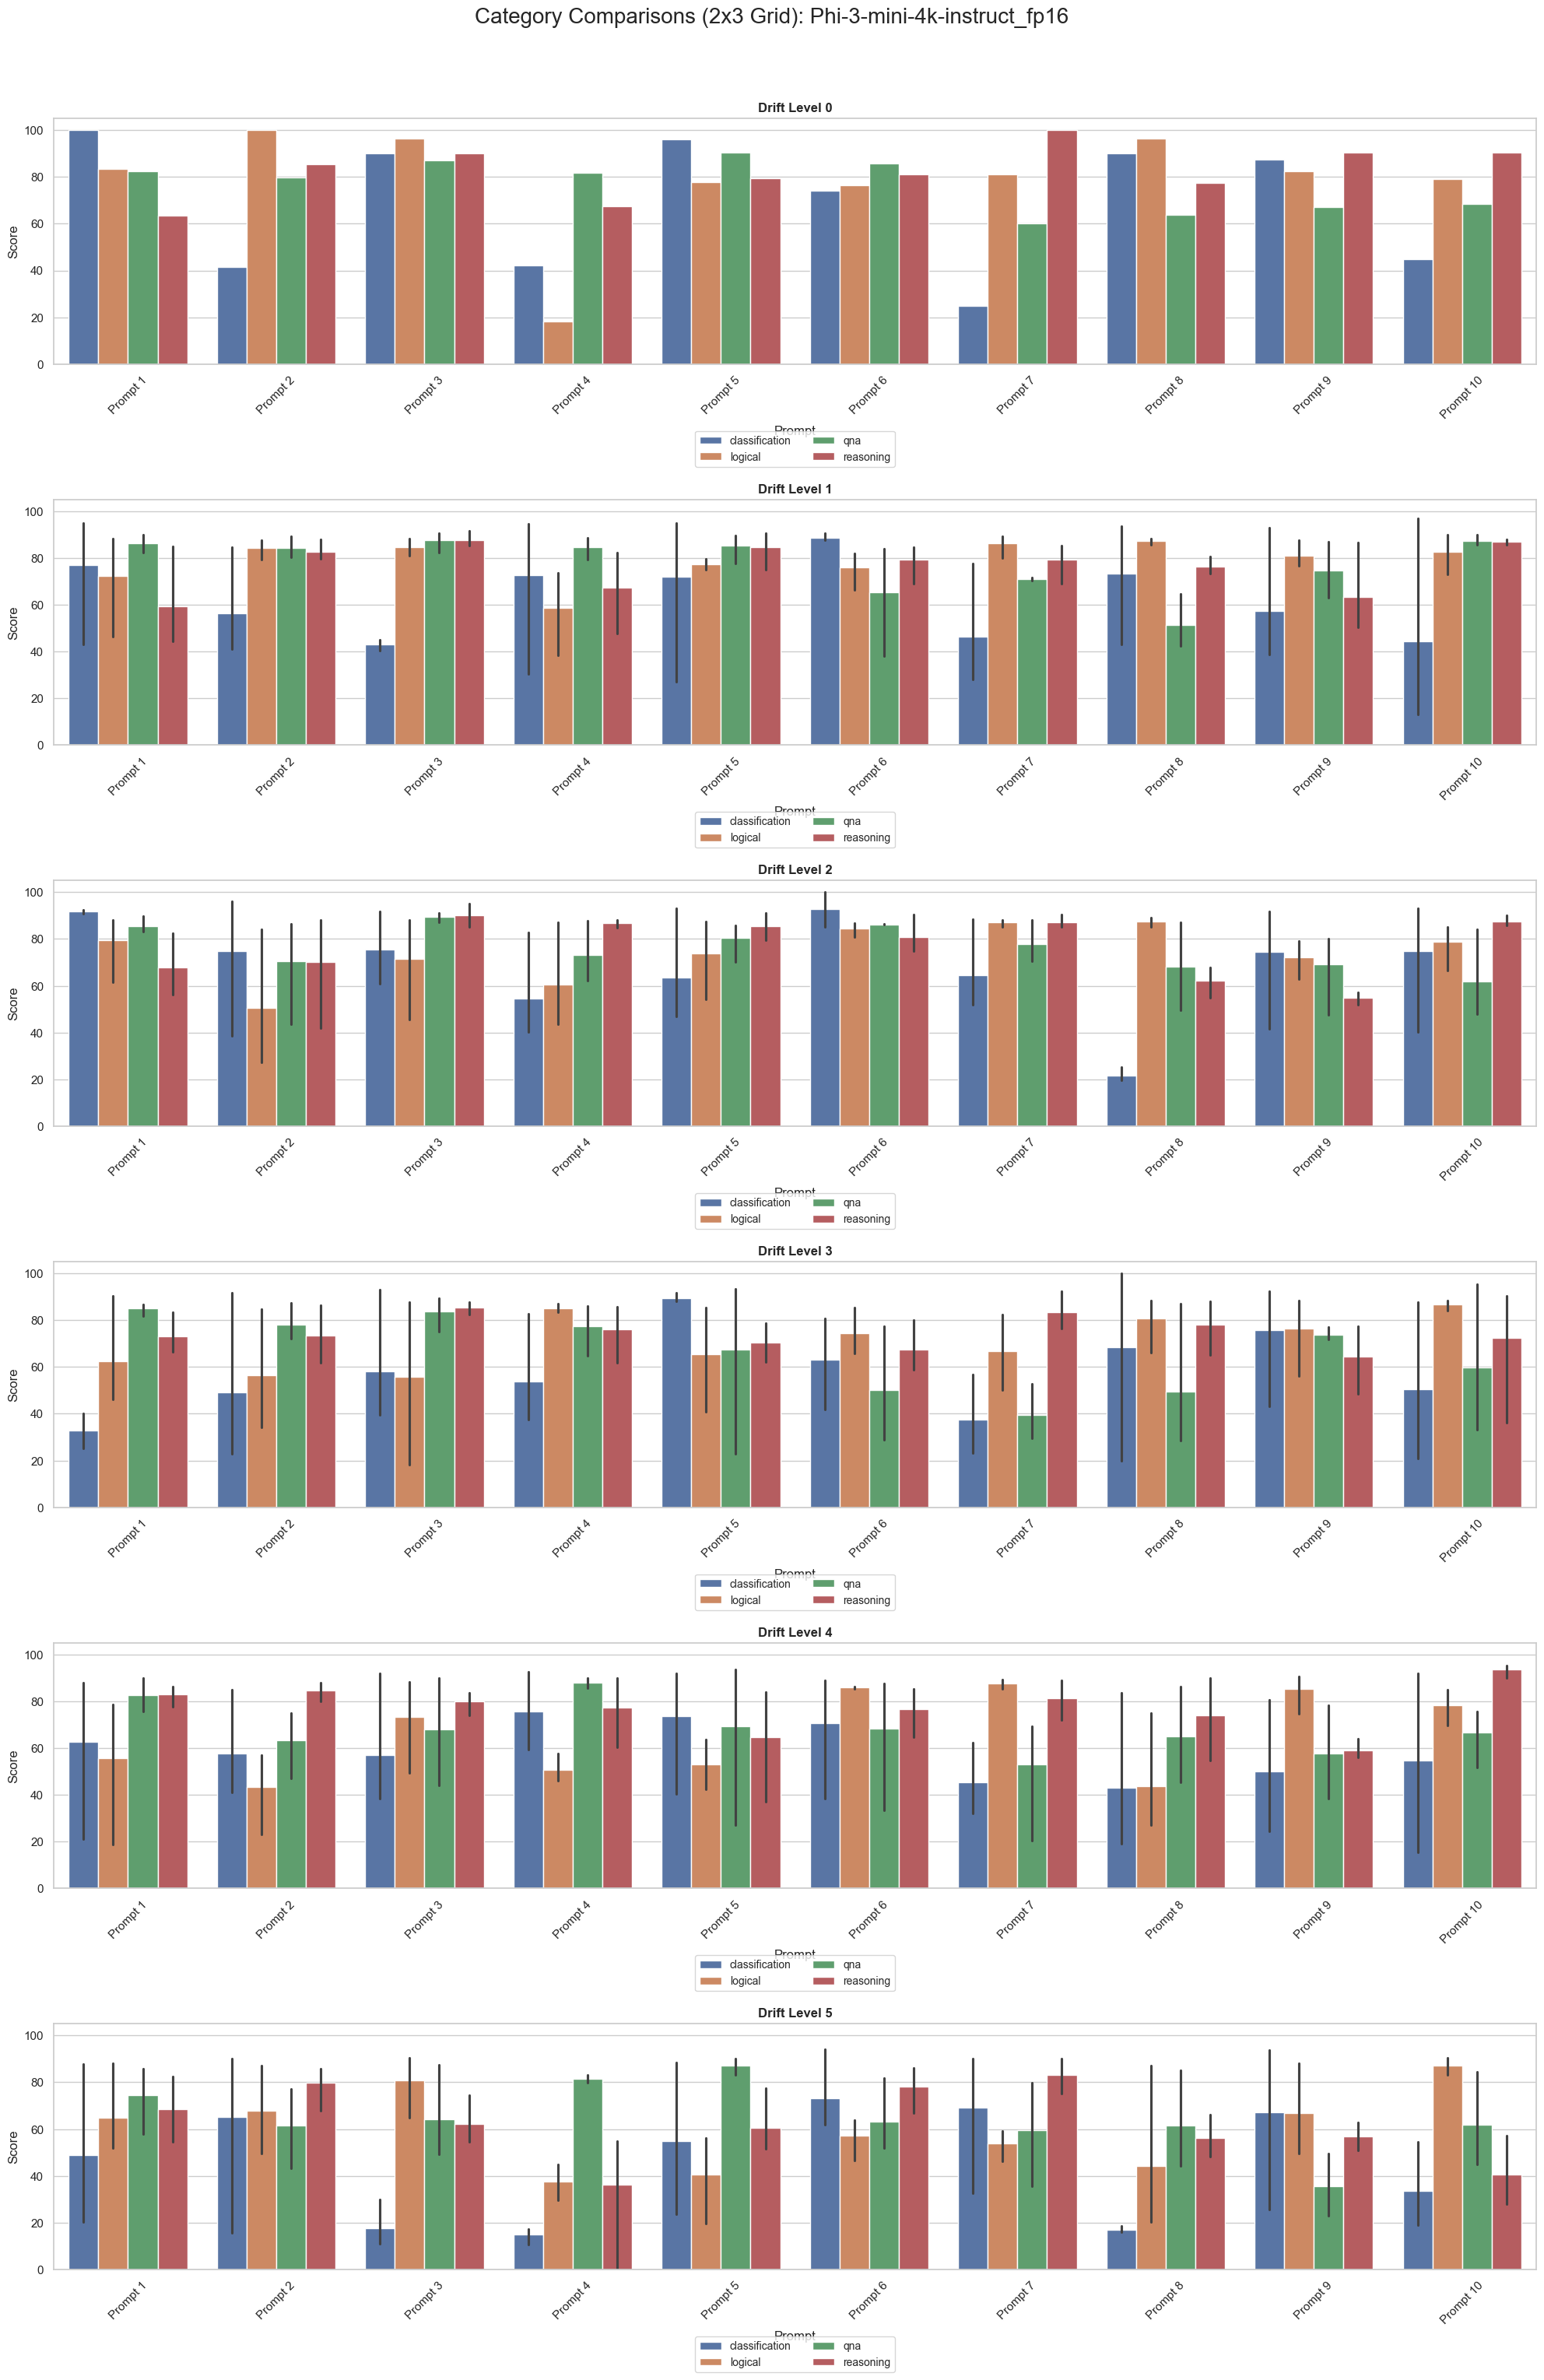

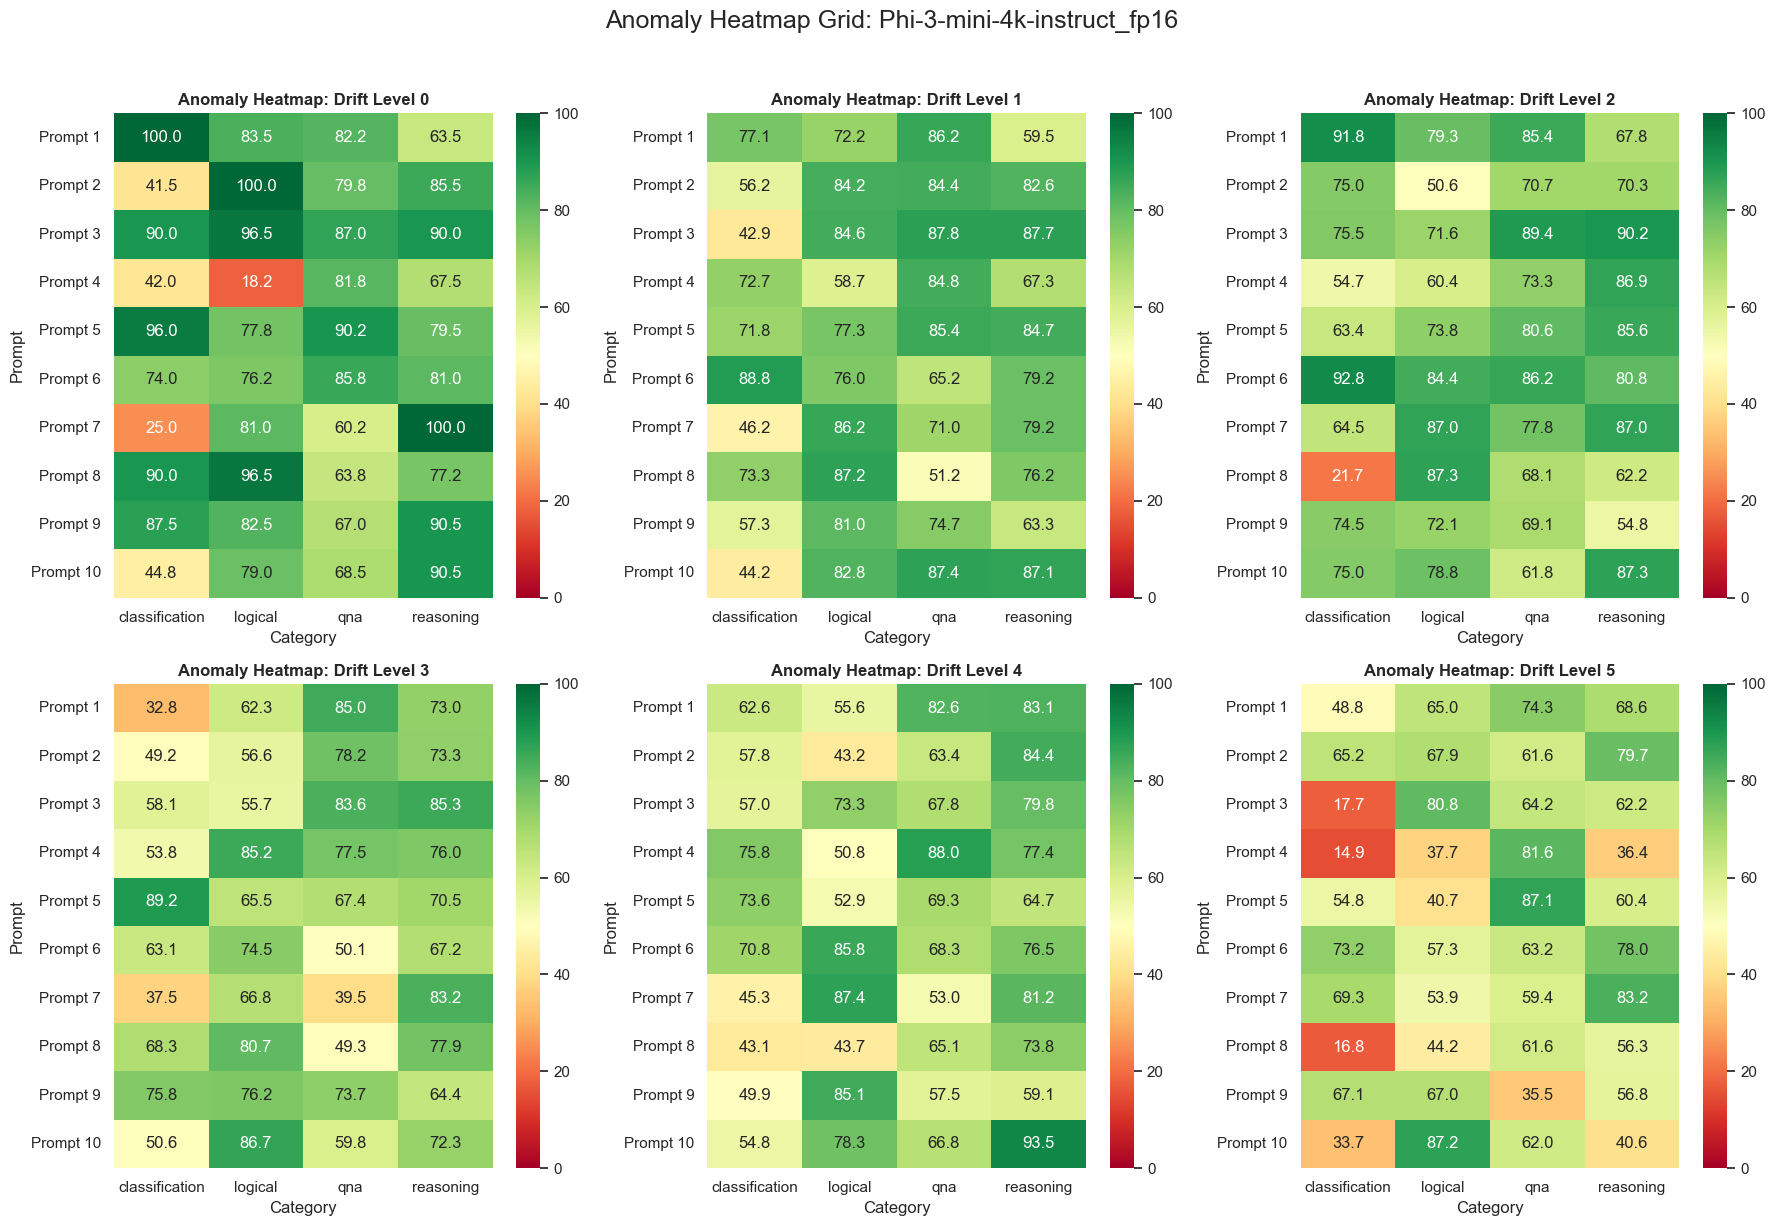


REPORT FOR: Mistral-7B-Instruct-v0.2_4bit


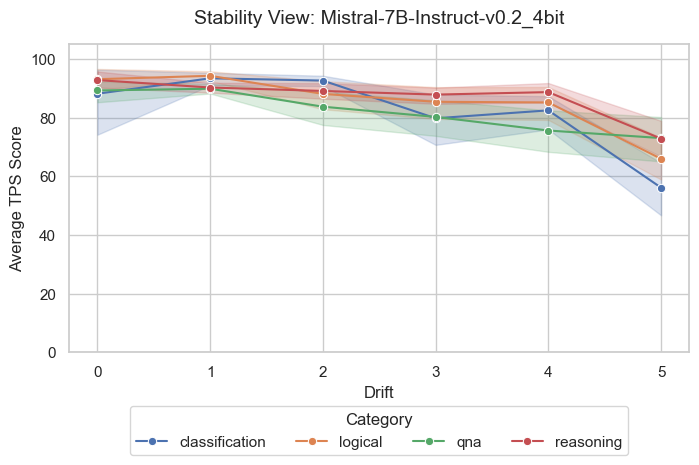

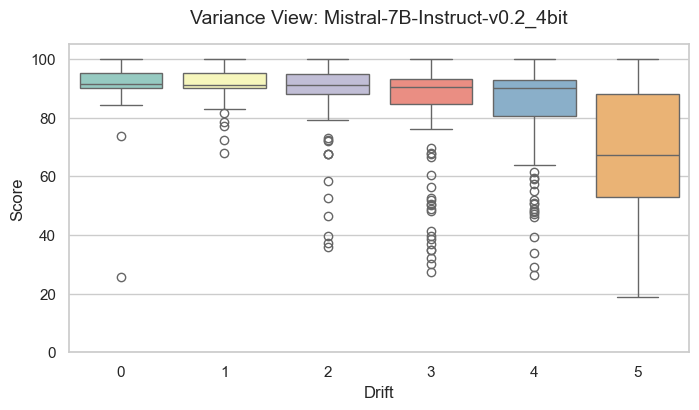

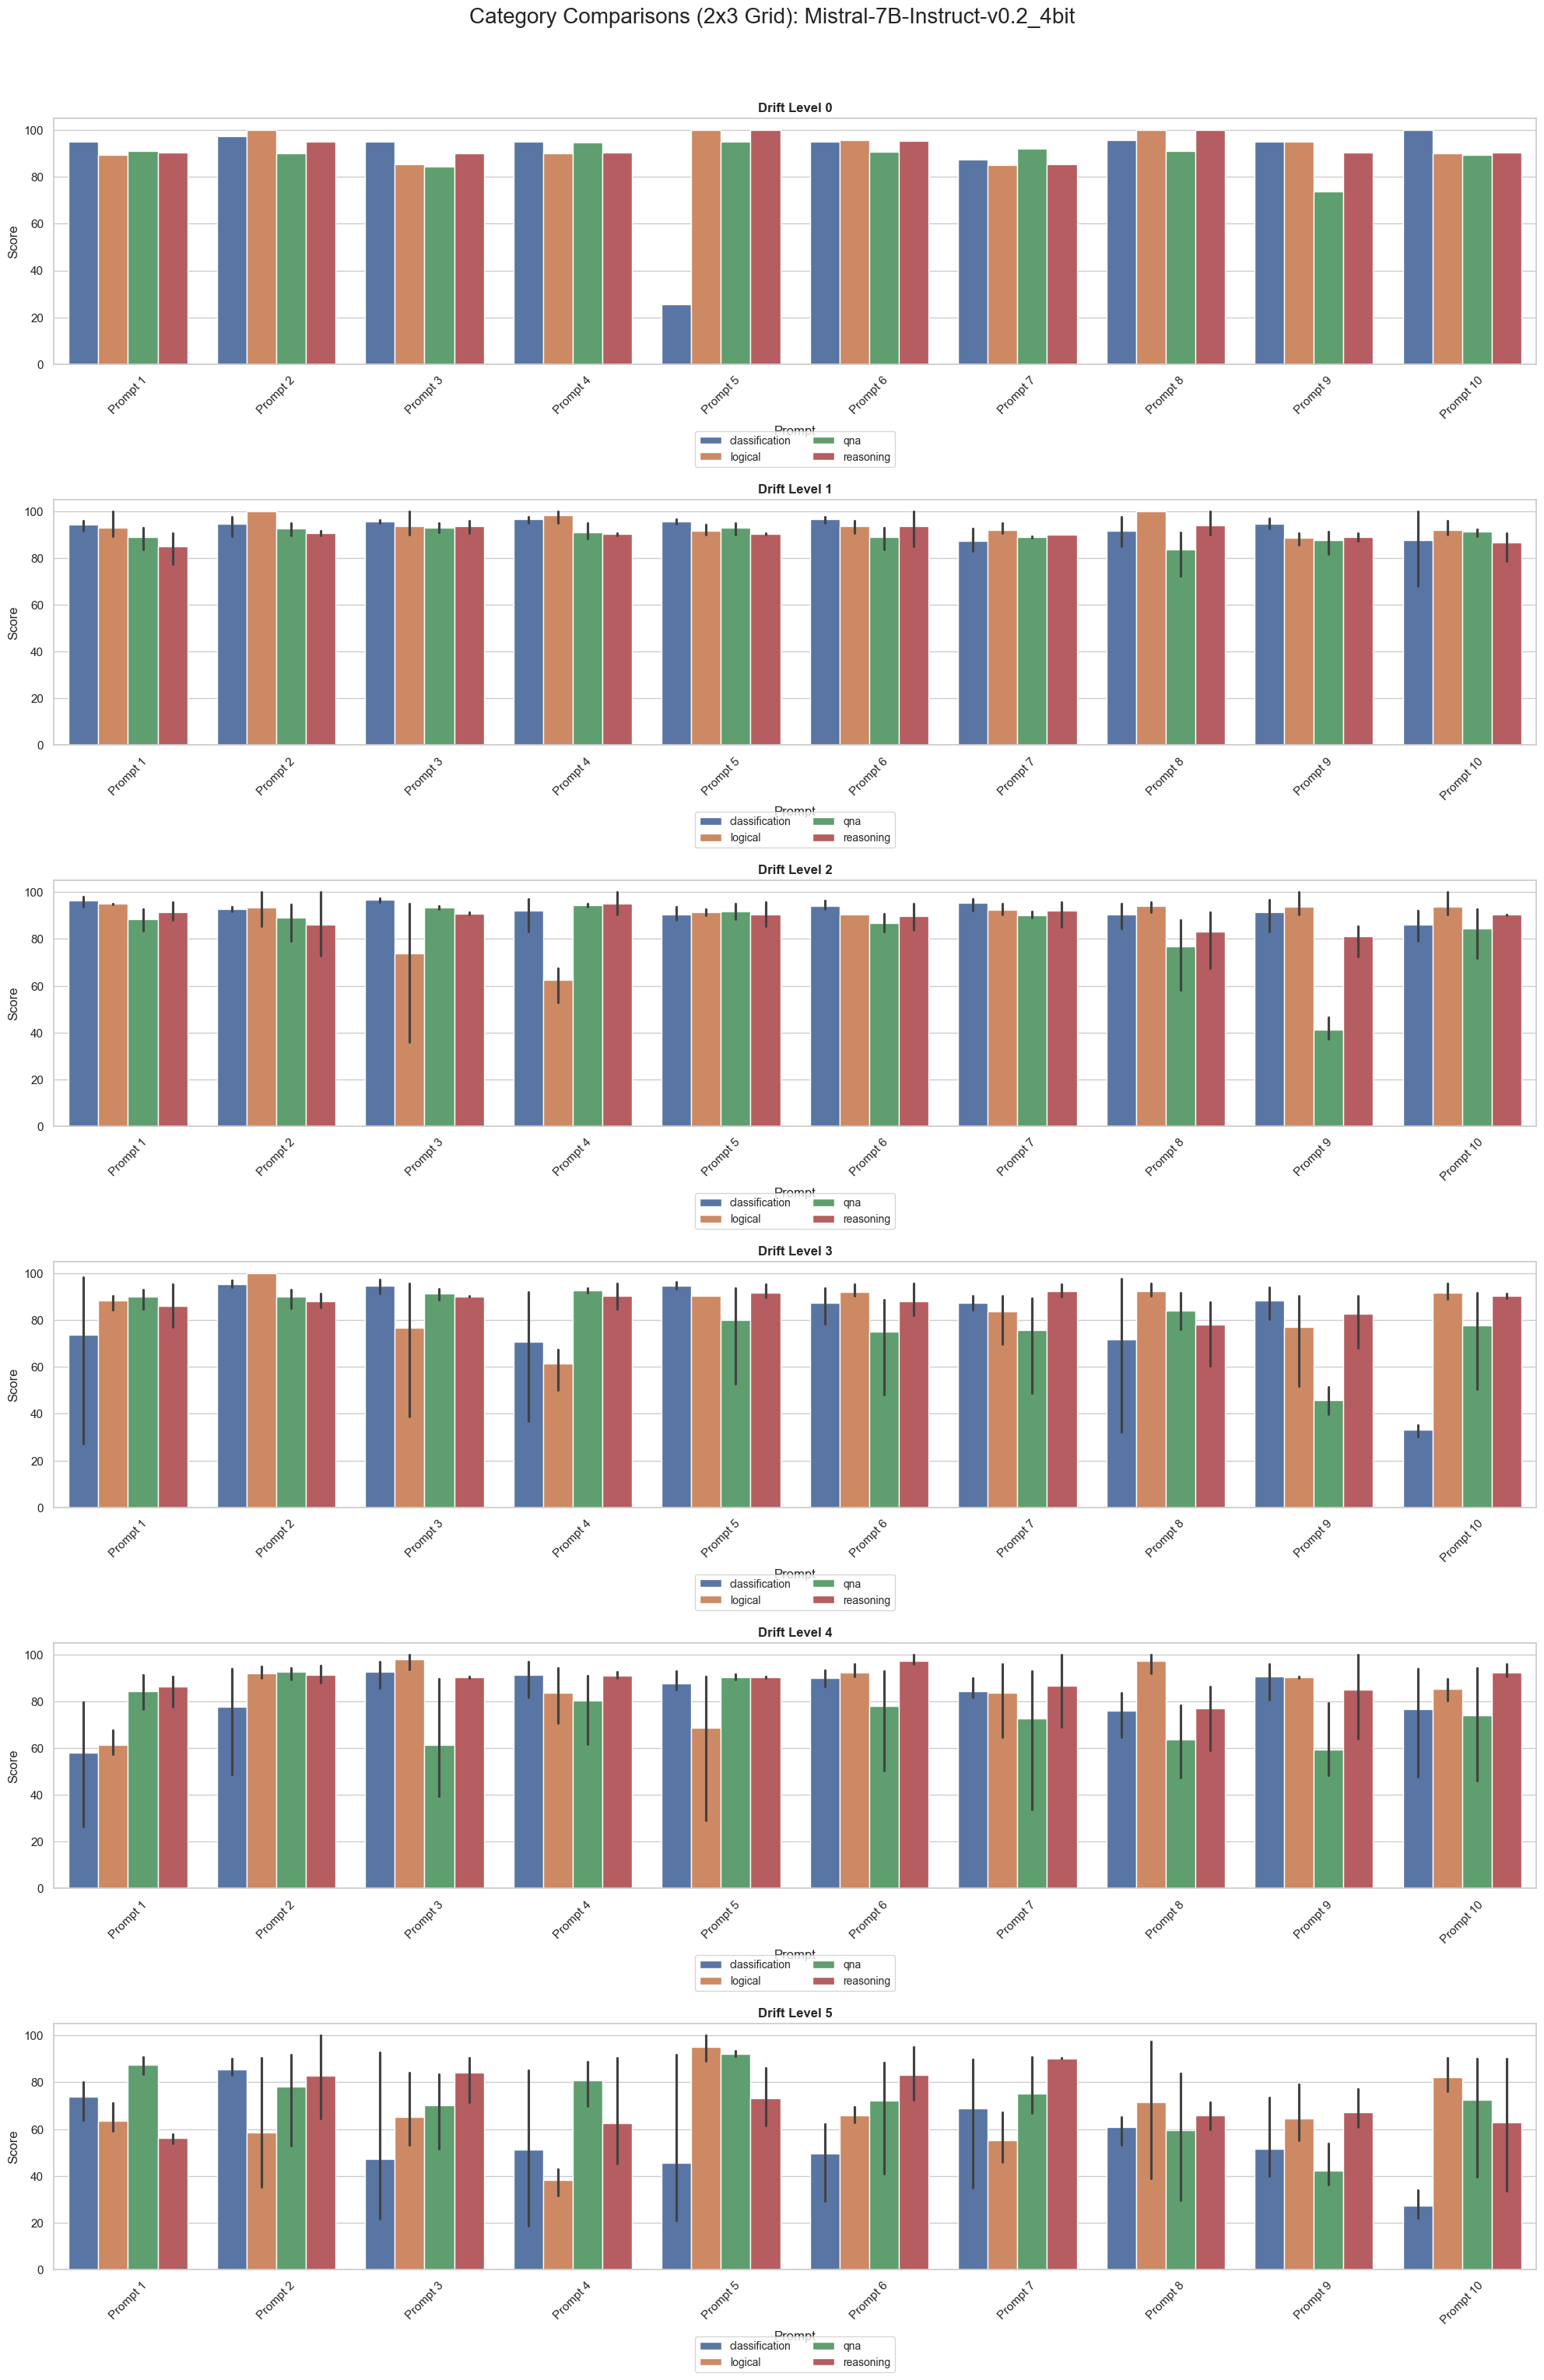

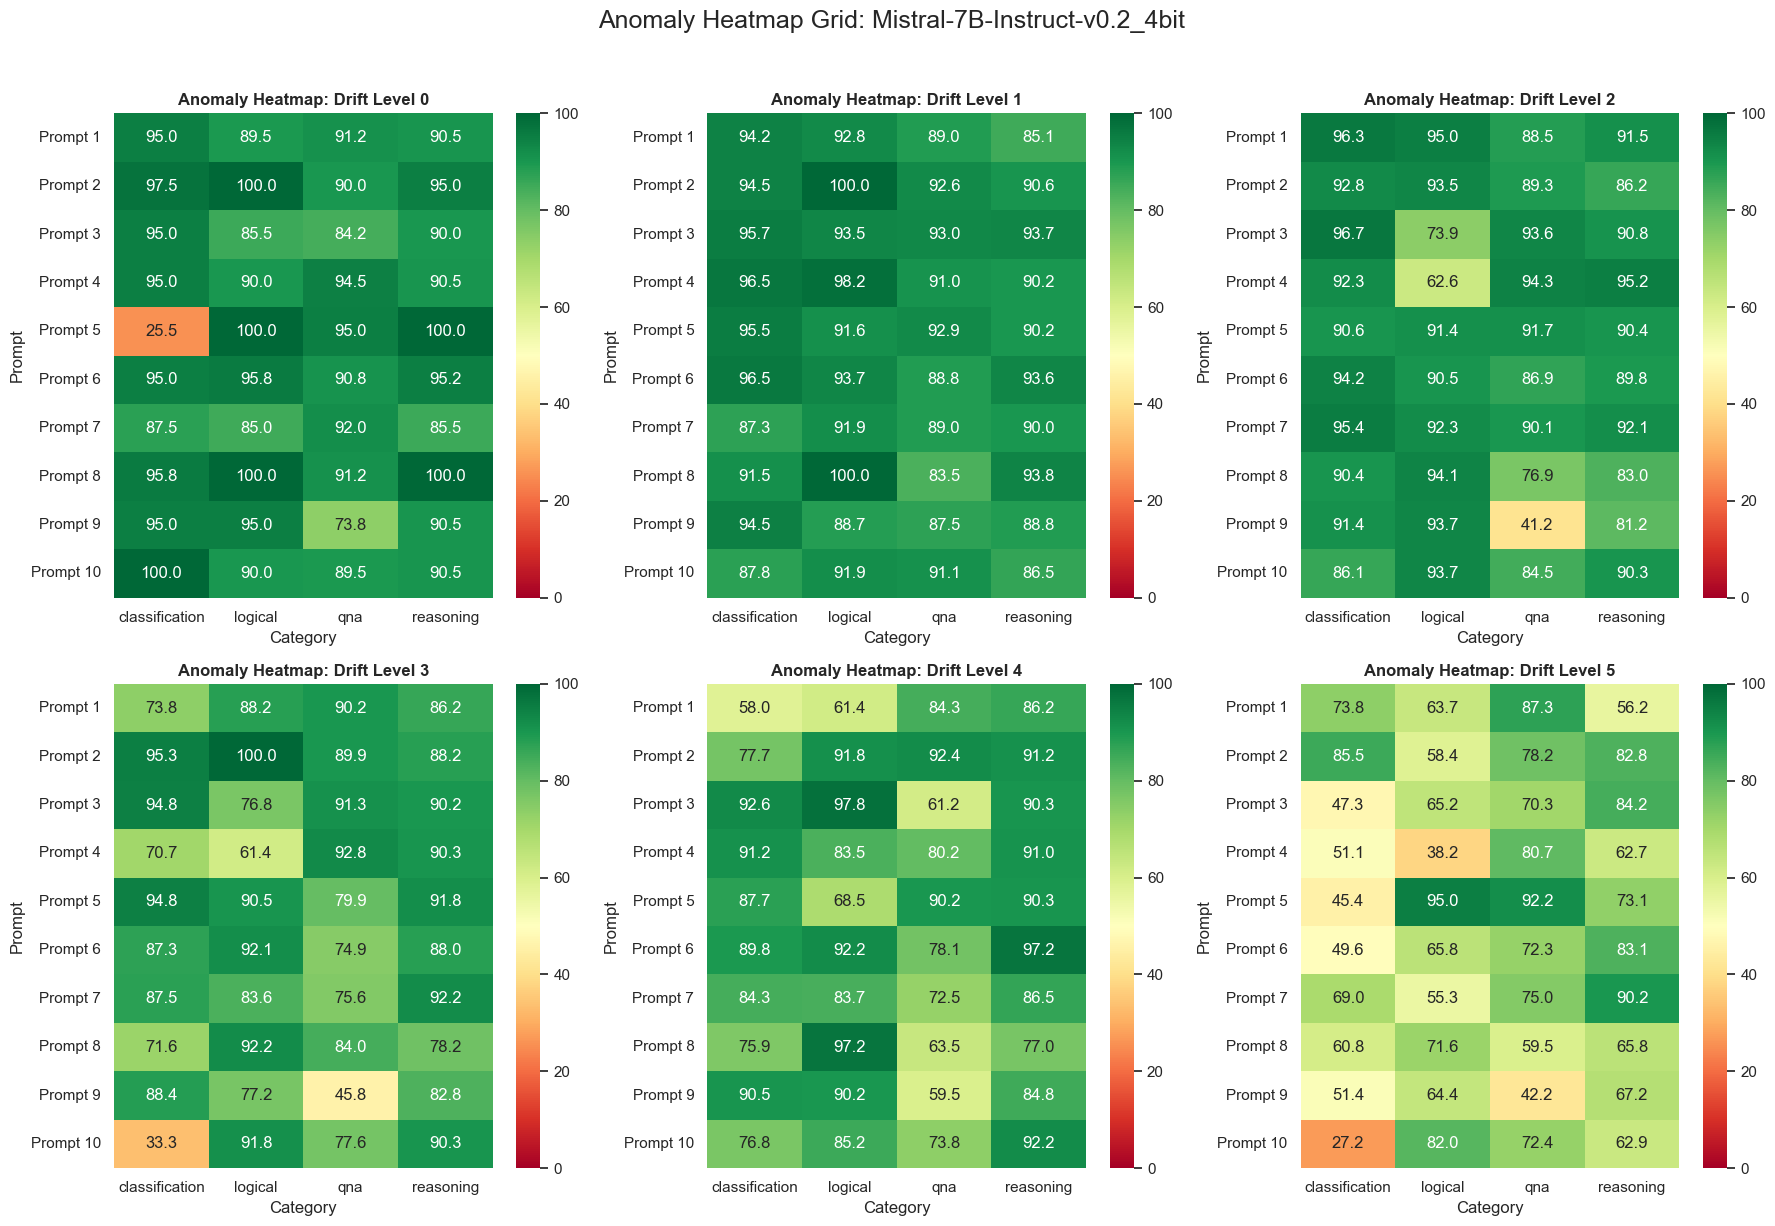


REPORT FOR: Mistral-7B-Instruct-v0.2_8bit


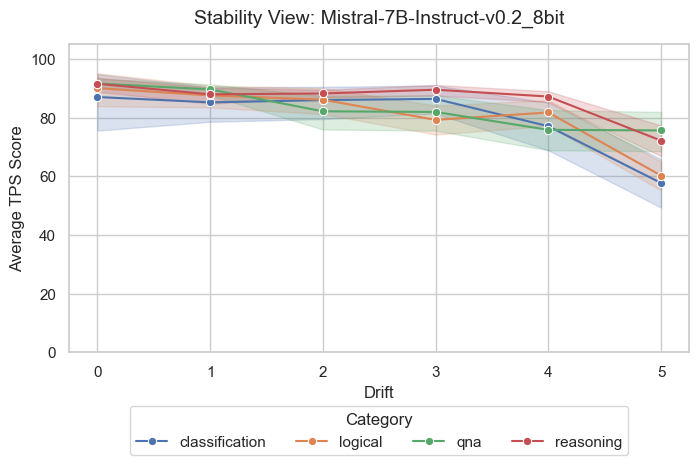

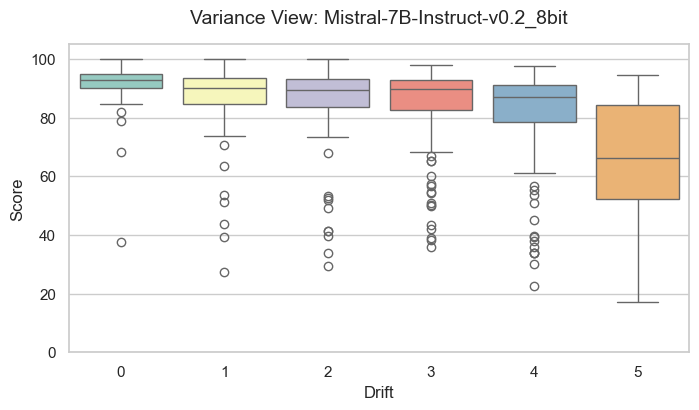

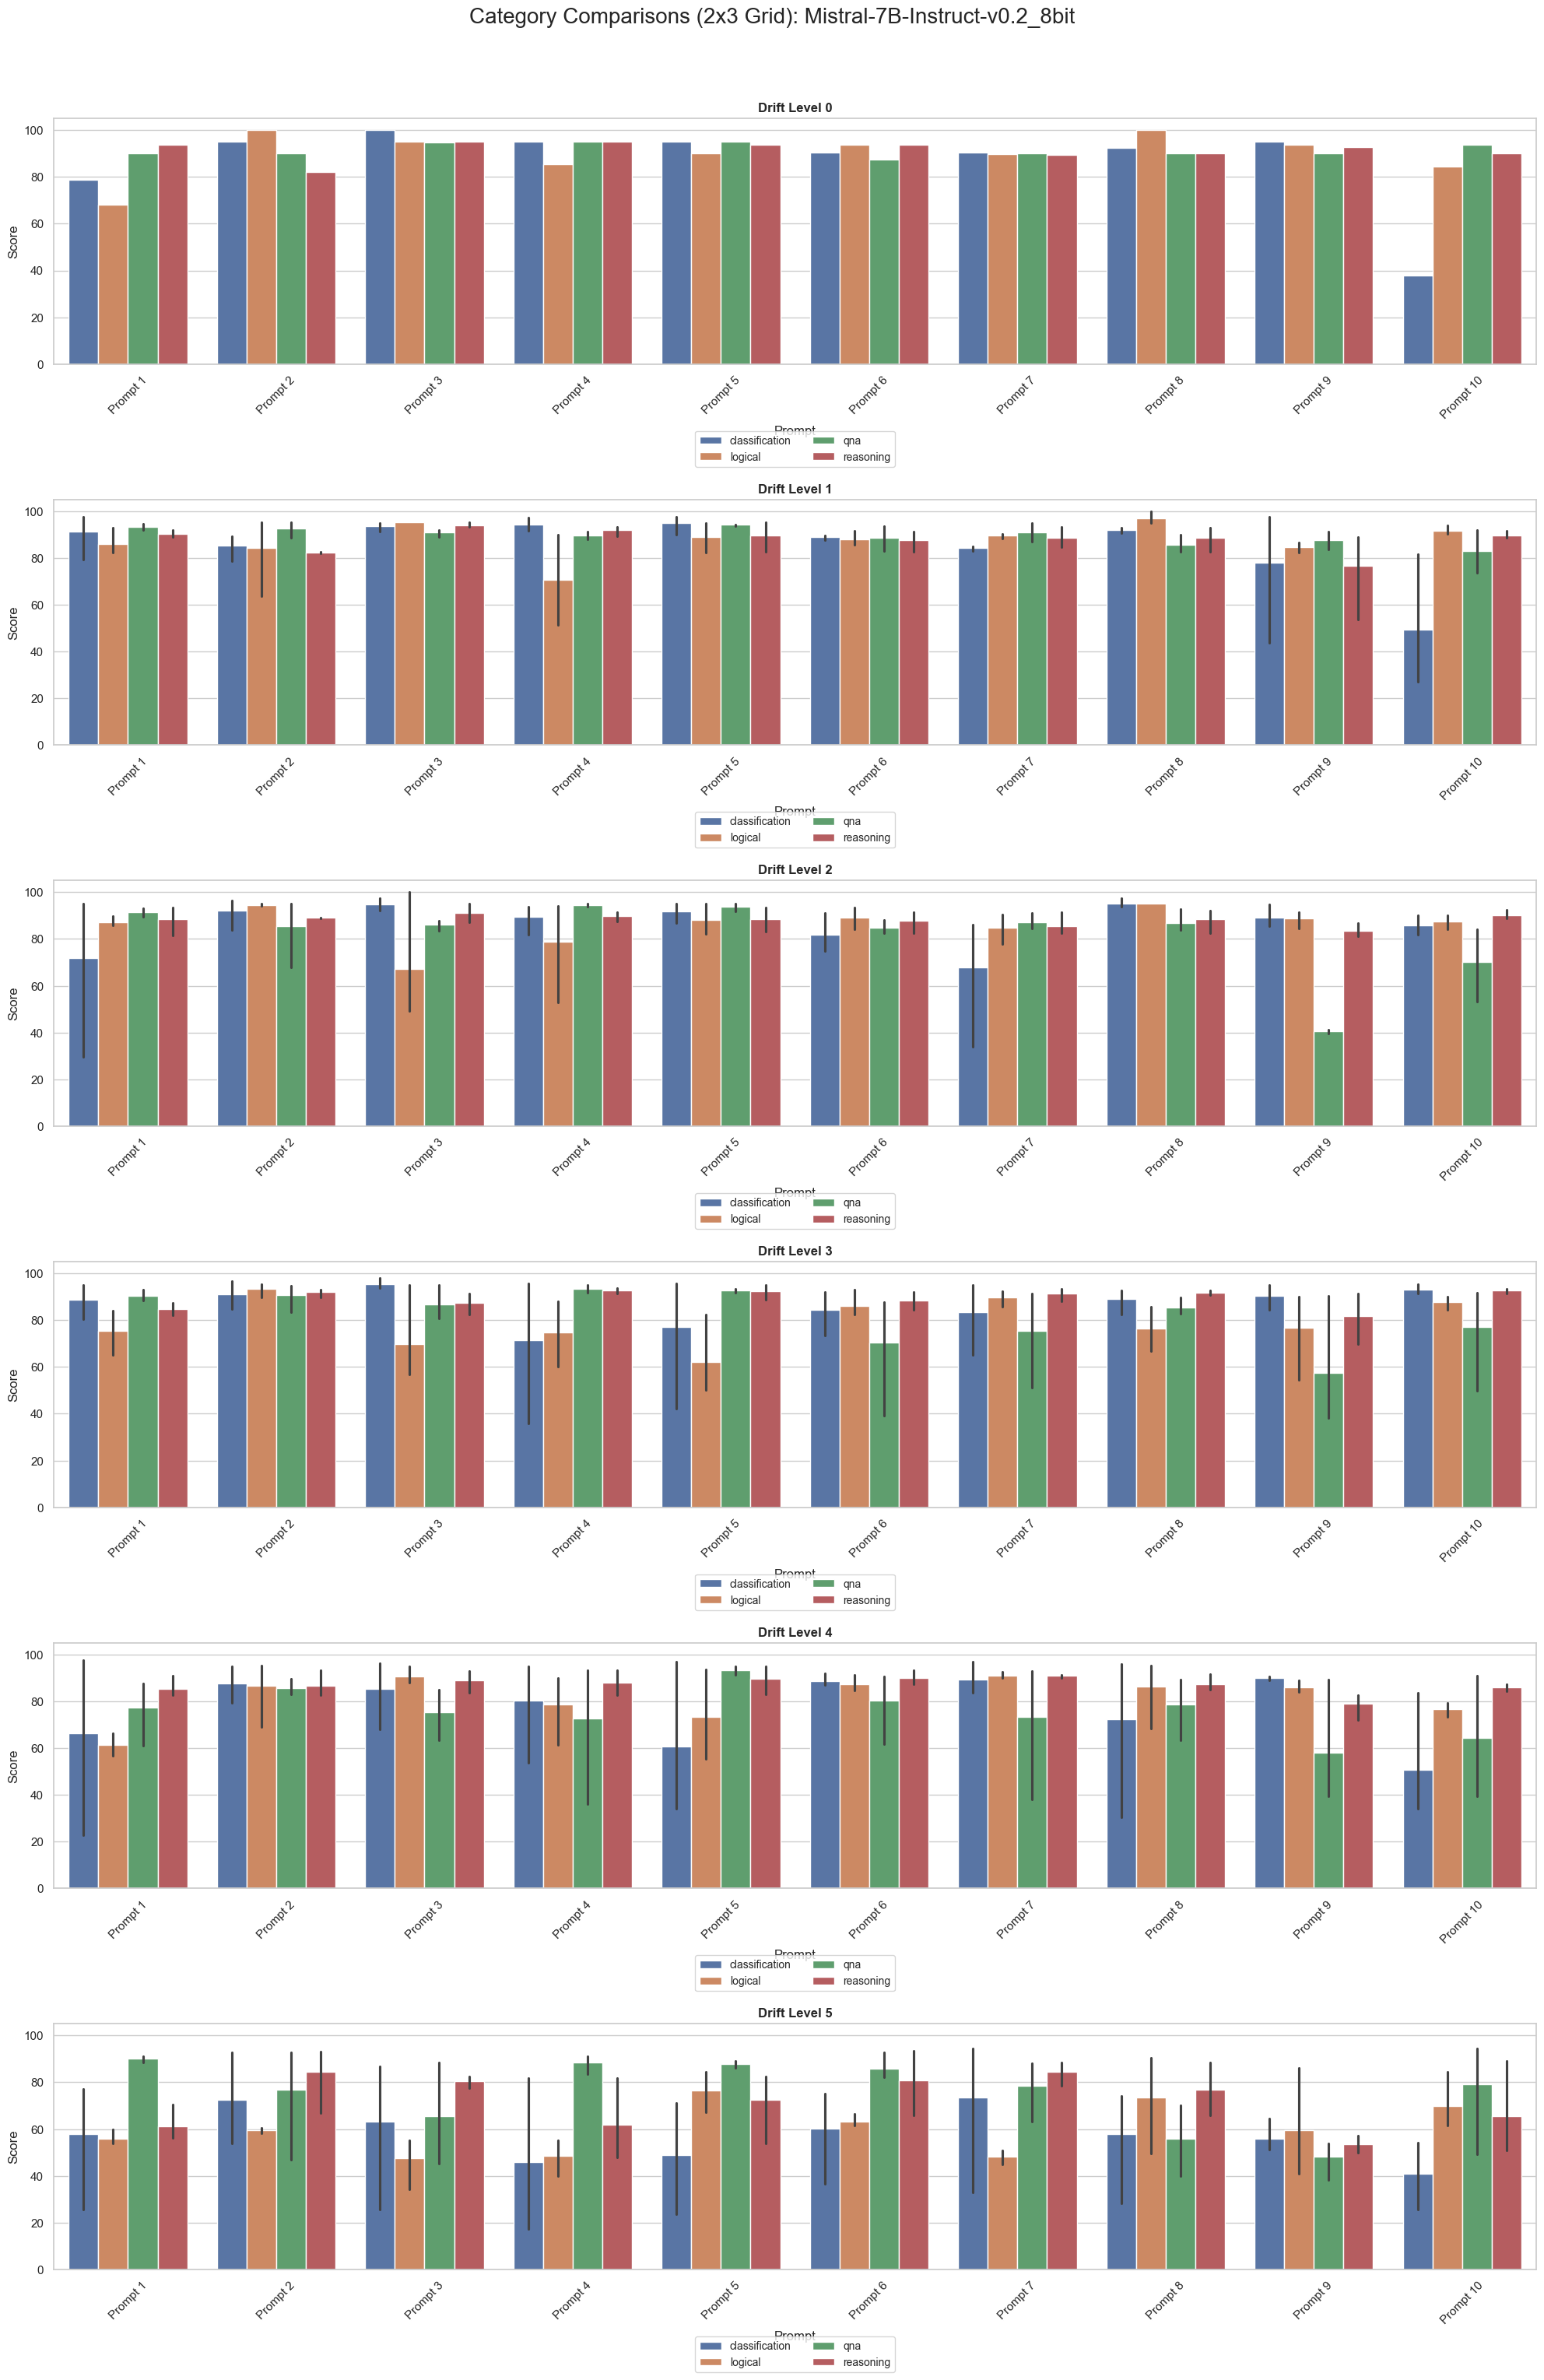

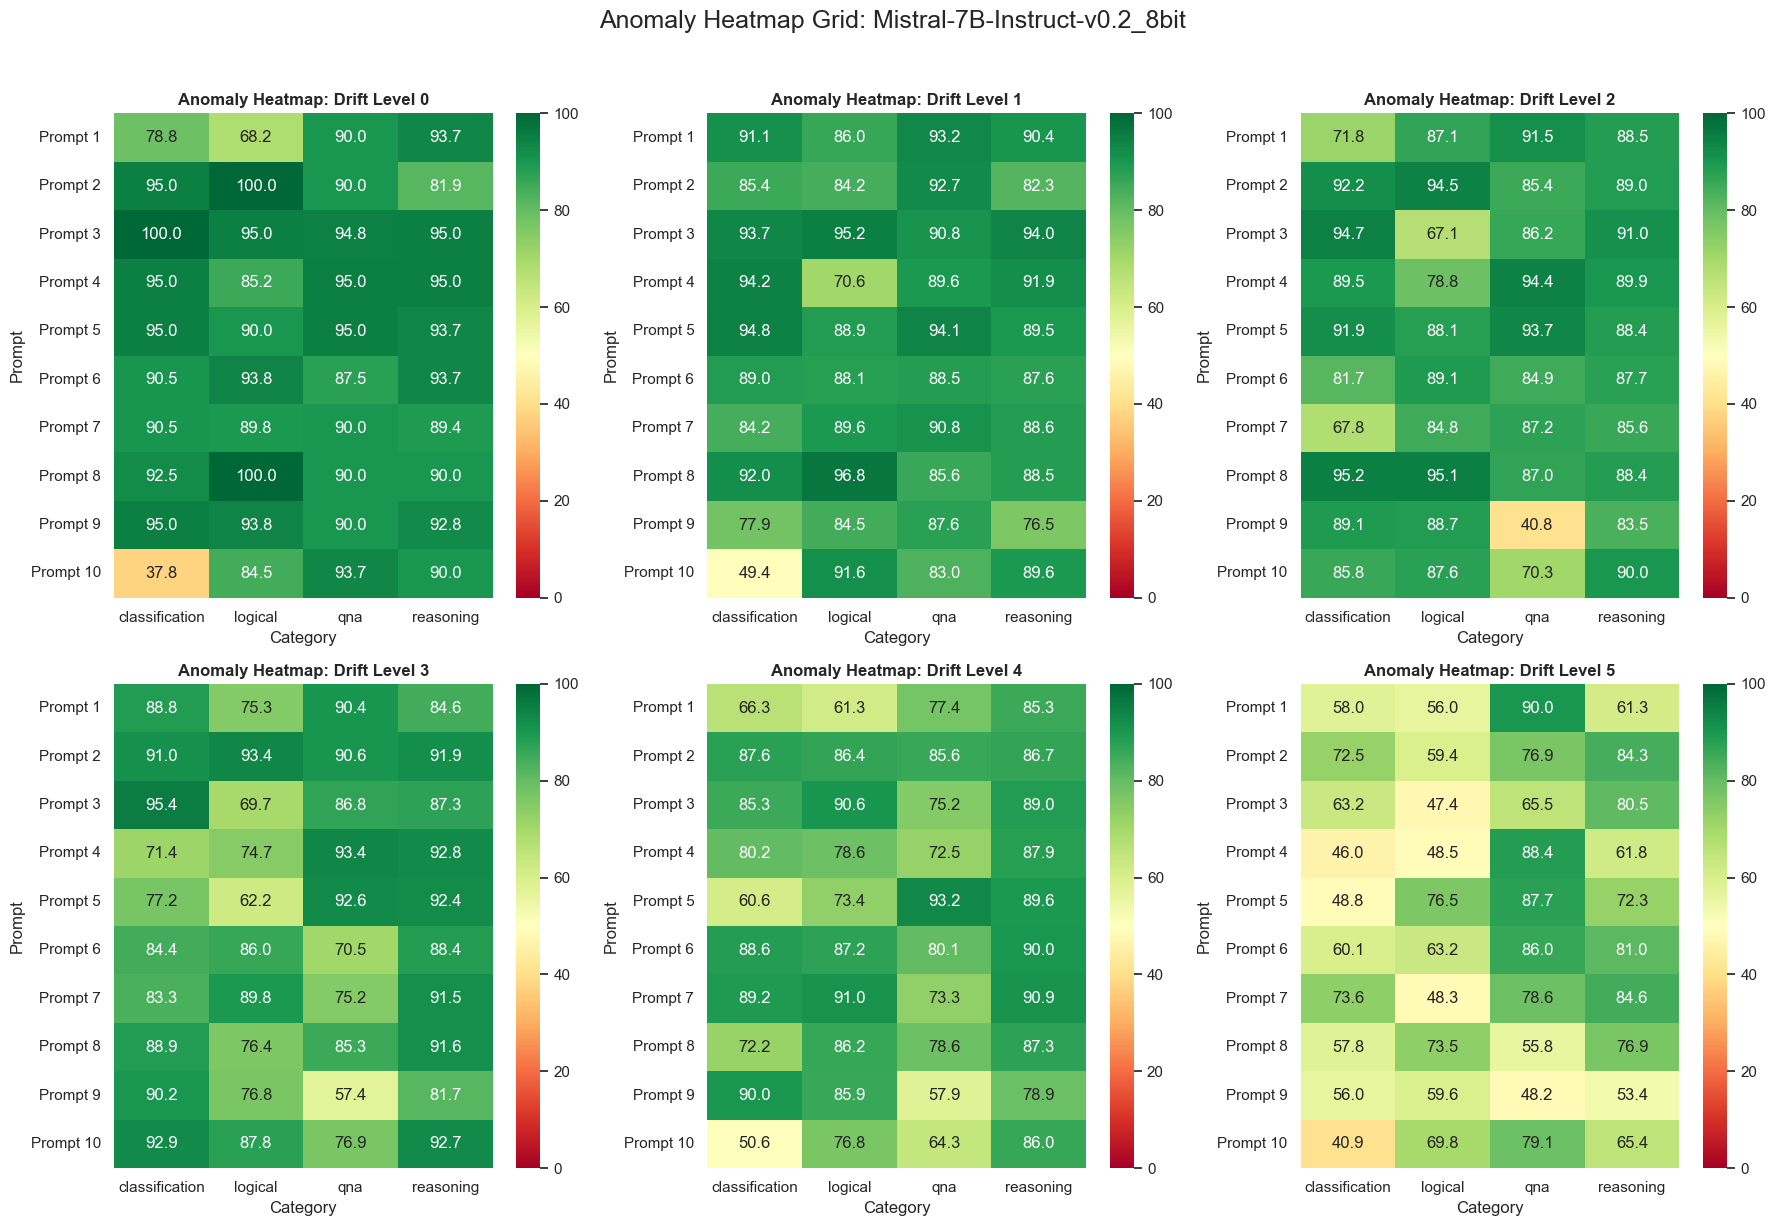


REPORT FOR: Mistral-7B-Instruct-v0.2_fp16


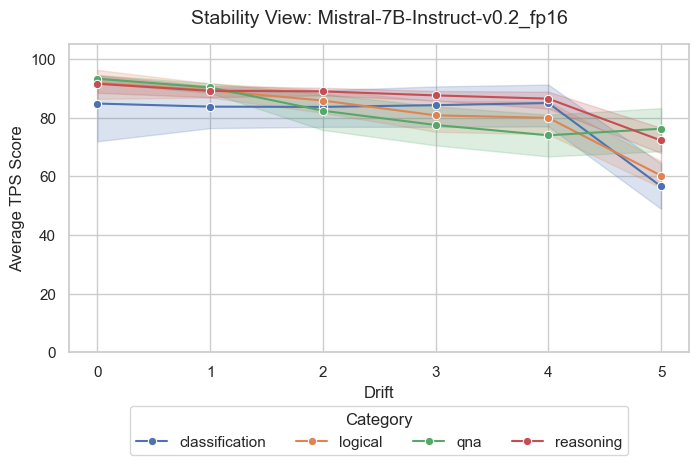

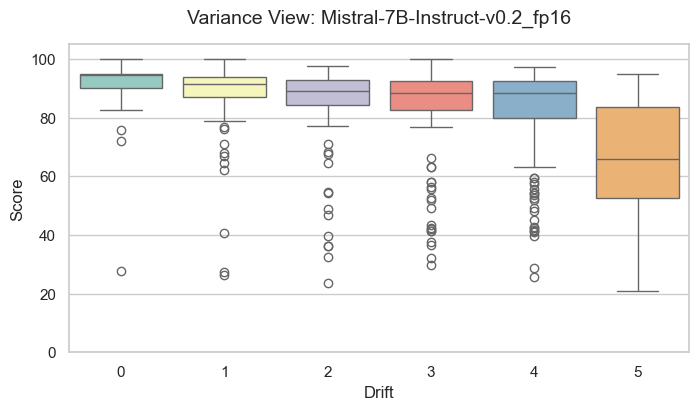

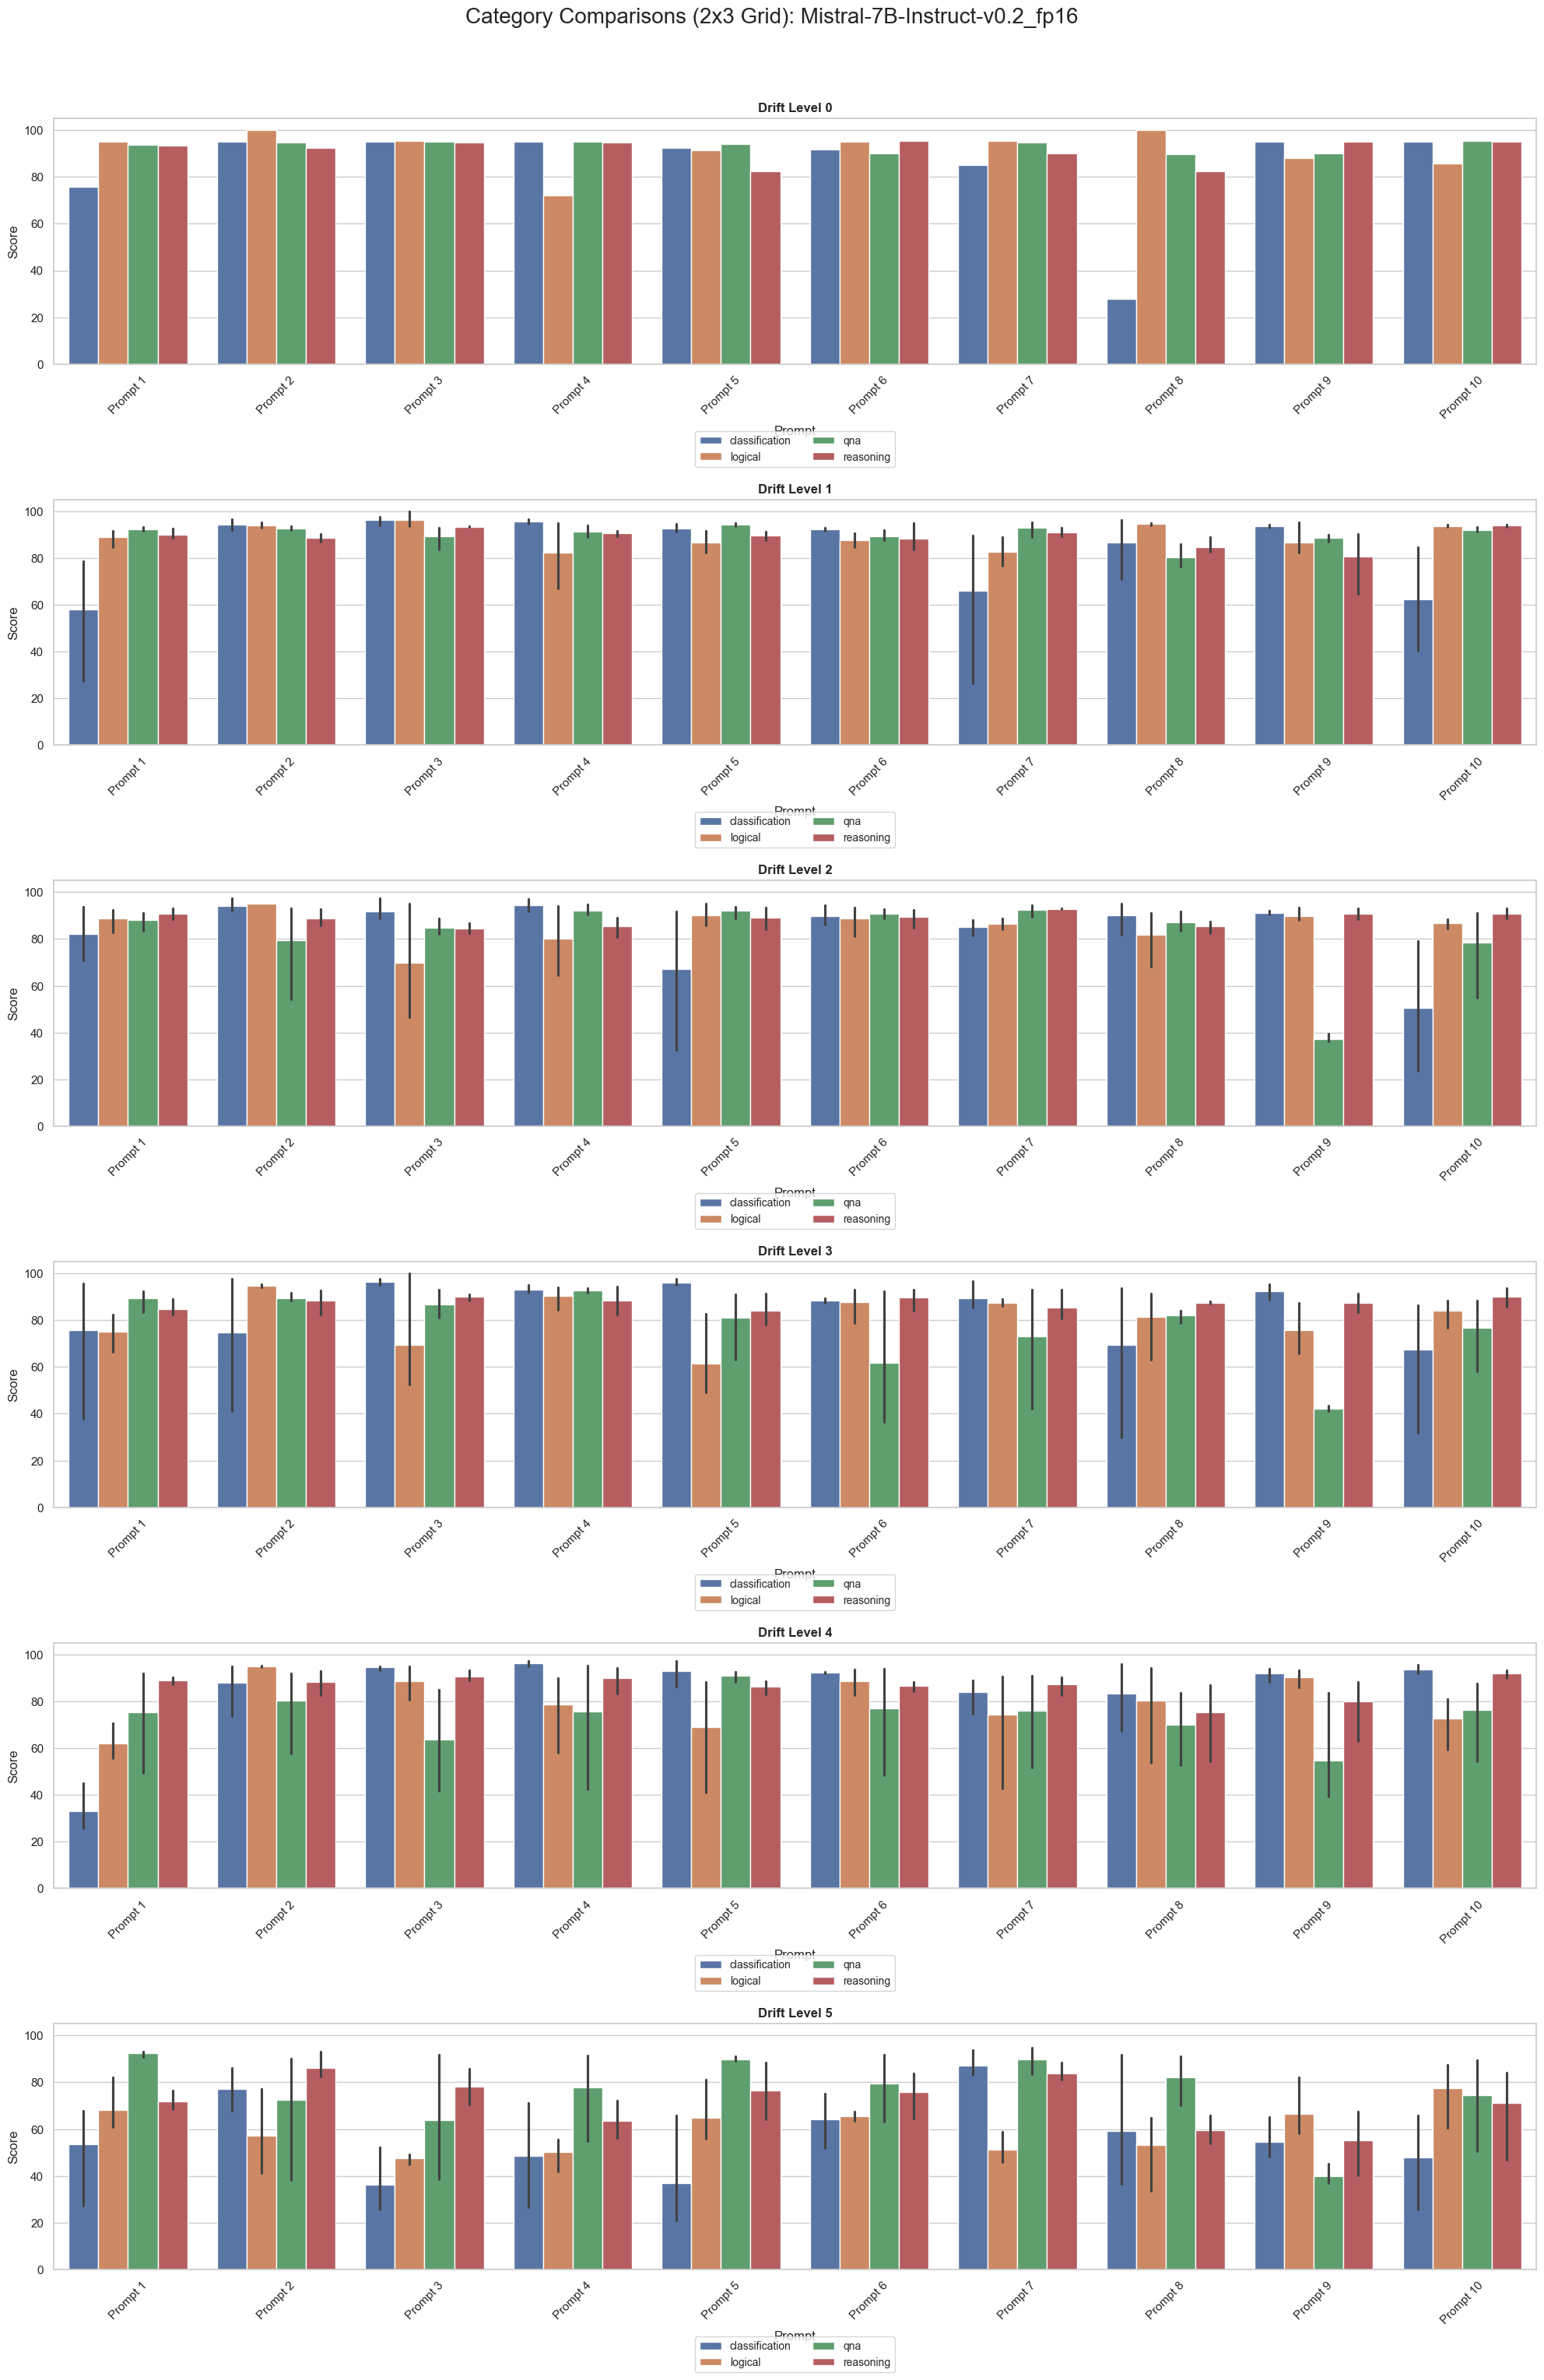

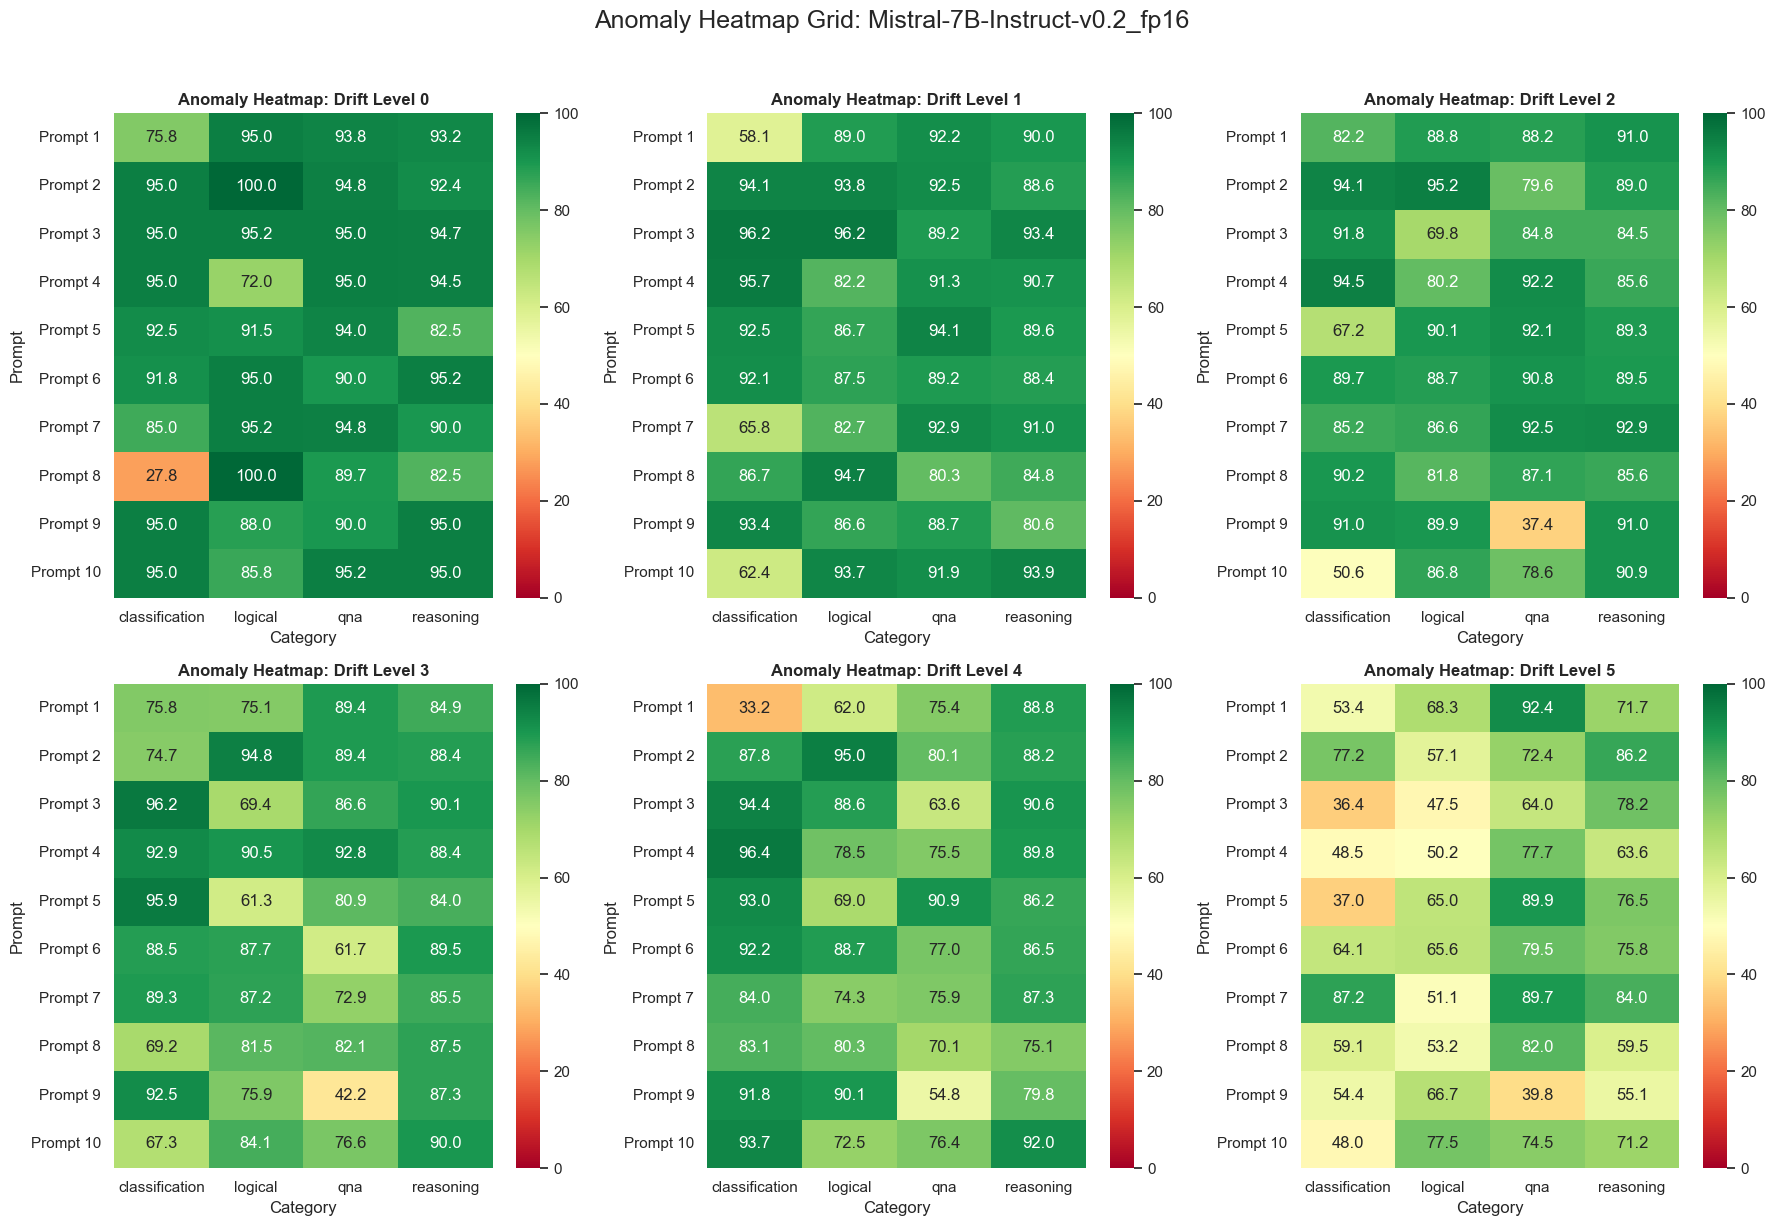

In [92]:
run_visualizations(r"../5_TPS_calculation/TPS")

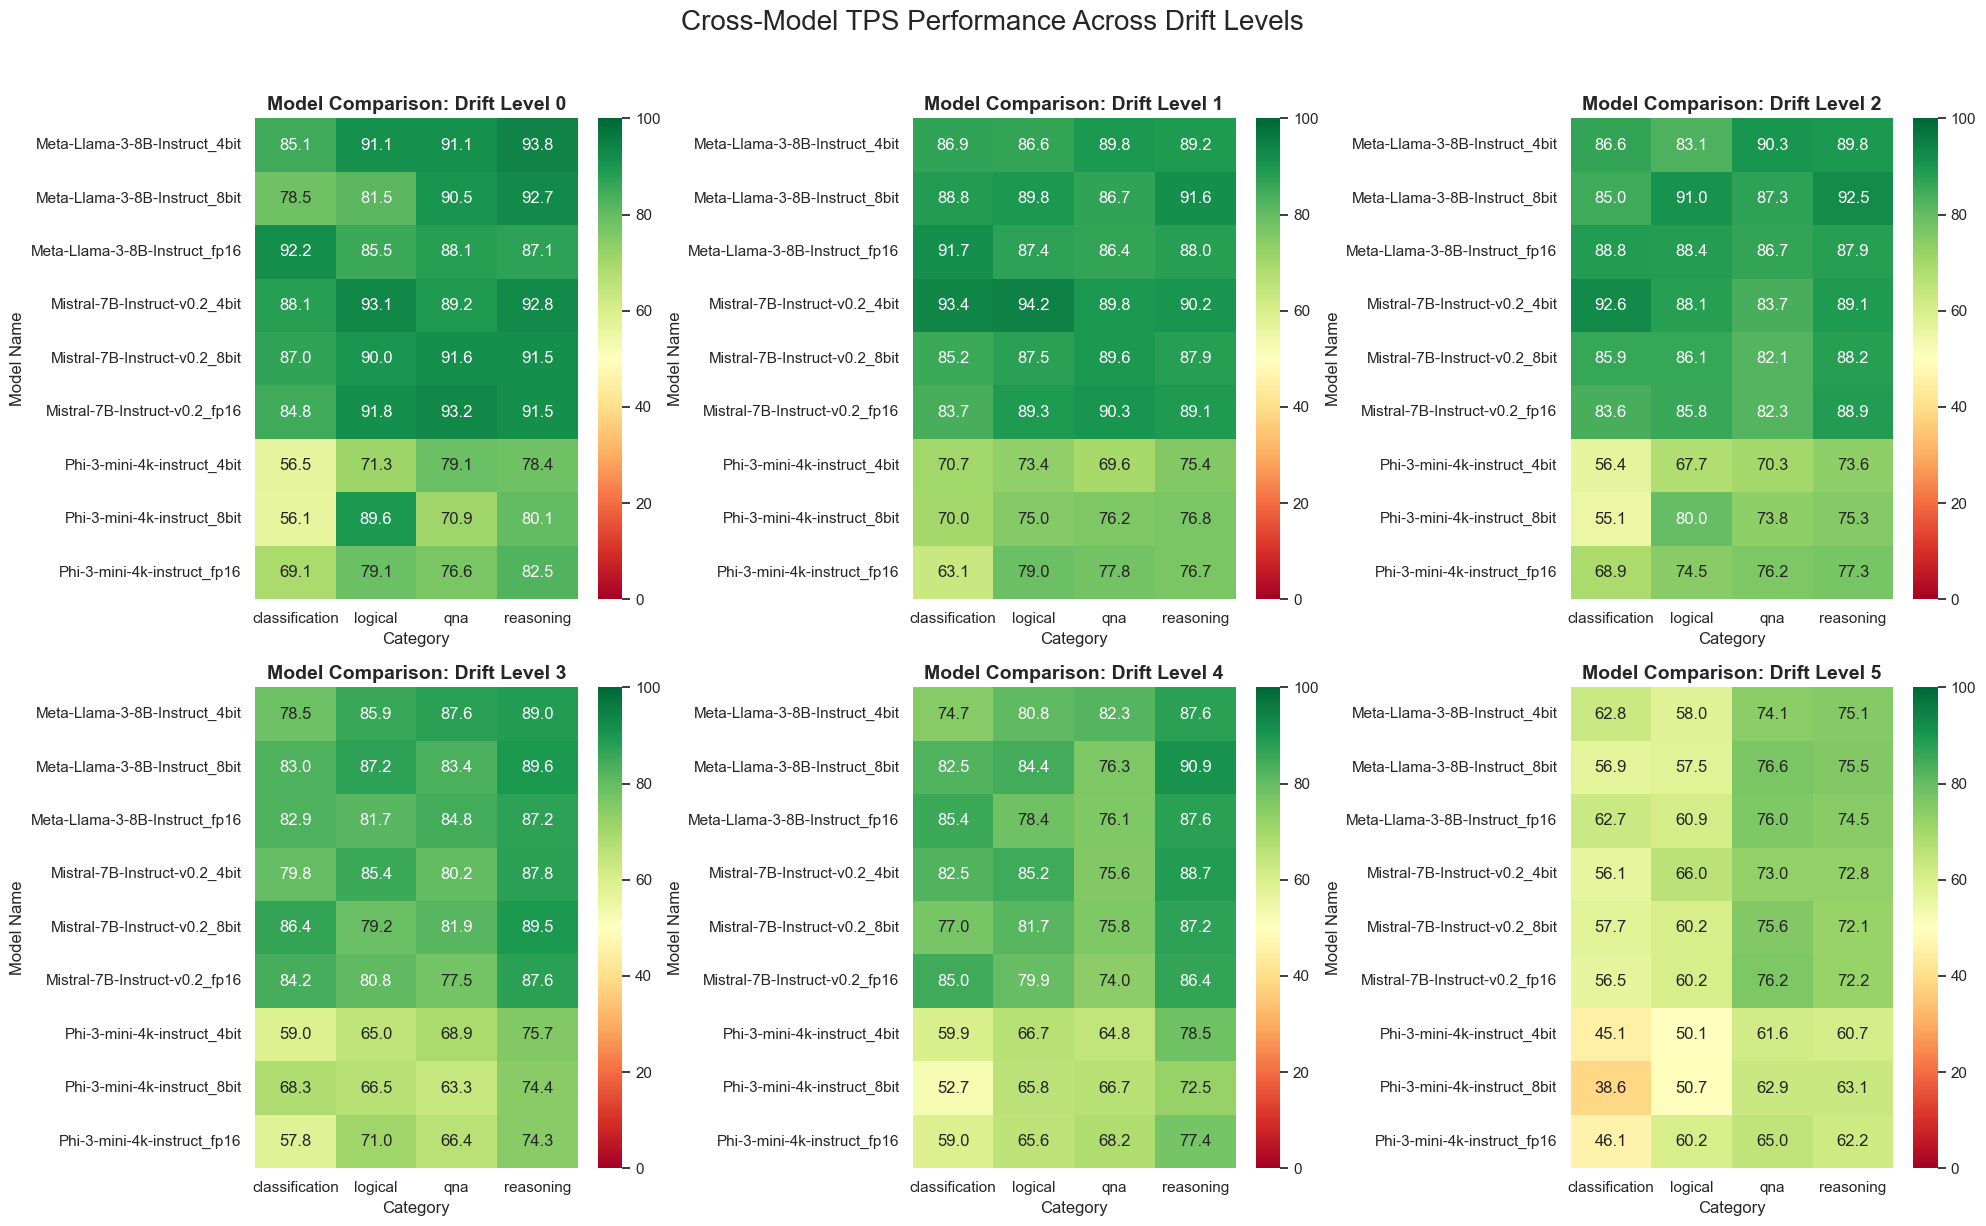

In [108]:
def plot_model_comparison_heatmaps(base_tps_dir):
    """Generates a 3x2 grid of heatmaps: Model Name (Y) vs Category (X)."""
    base_path = Path(base_tps_dir)
    all_model_data = []

    # 1. Collect and aggregate data from all models
    for json_file in base_path.glob("**/tps_scores_structured.json"):
        model_name = json_file.parent.name
        
        with open(json_file, 'r') as f:
            data = json.load(f)
            
        for entry in data:
            drift_lvl = entry.get("Drift_Level")
            for key, value in entry.items():
                if key == "Drift_Level" or value is None:
                    continue
                
                # Parse Category
                category = key.split(" (")[1].replace(")", "")
                
                # Calculate Average for this specific prompt/category
                if isinstance(value, dict):
                    valid_vals = [v for v in value.values() if v is not None]
                    avg_score = sum(valid_vals) / len(valid_vals) if valid_vals else 0
                else:
                    avg_score = value
                
                all_model_data.append({
                    "Model": model_name,
                    "Drift": drift_lvl,
                    "Category": category,
                    "Score": avg_score
                })

    df_all = pd.DataFrame(all_model_data)
    if df_all.empty:
        print("No data found to compare models.")
        return

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    levels = sorted(df_all['Drift'].unique())

    for i, lvl in enumerate(levels):
        subset = df_all[df_all['Drift'] == lvl]
        
        # Pivot: Index is Model, Columns are Category, Values are Average of all 10 prompts
        pivot_df = subset.pivot_table(index="Model", columns="Category", values="Score", aggfunc='mean')
        
        sns.heatmap(pivot_df, annot=True, cmap="RdYlGn", vmin=0, vmax=100, fmt=".1f", ax=axes[i])
        axes[i].set_title(f"Model Comparison: Drift Level {lvl}", fontweight='bold', fontsize=14)
        axes[i].set_ylabel("Model Name")
        axes[i].set_xlabel("Category")

    plt.suptitle("Cross-Model TPS Performance Across Drift Levels", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

# To run this specific visualization:
plot_model_comparison_heatmaps(r"../5_TPS_calculation/TPS")

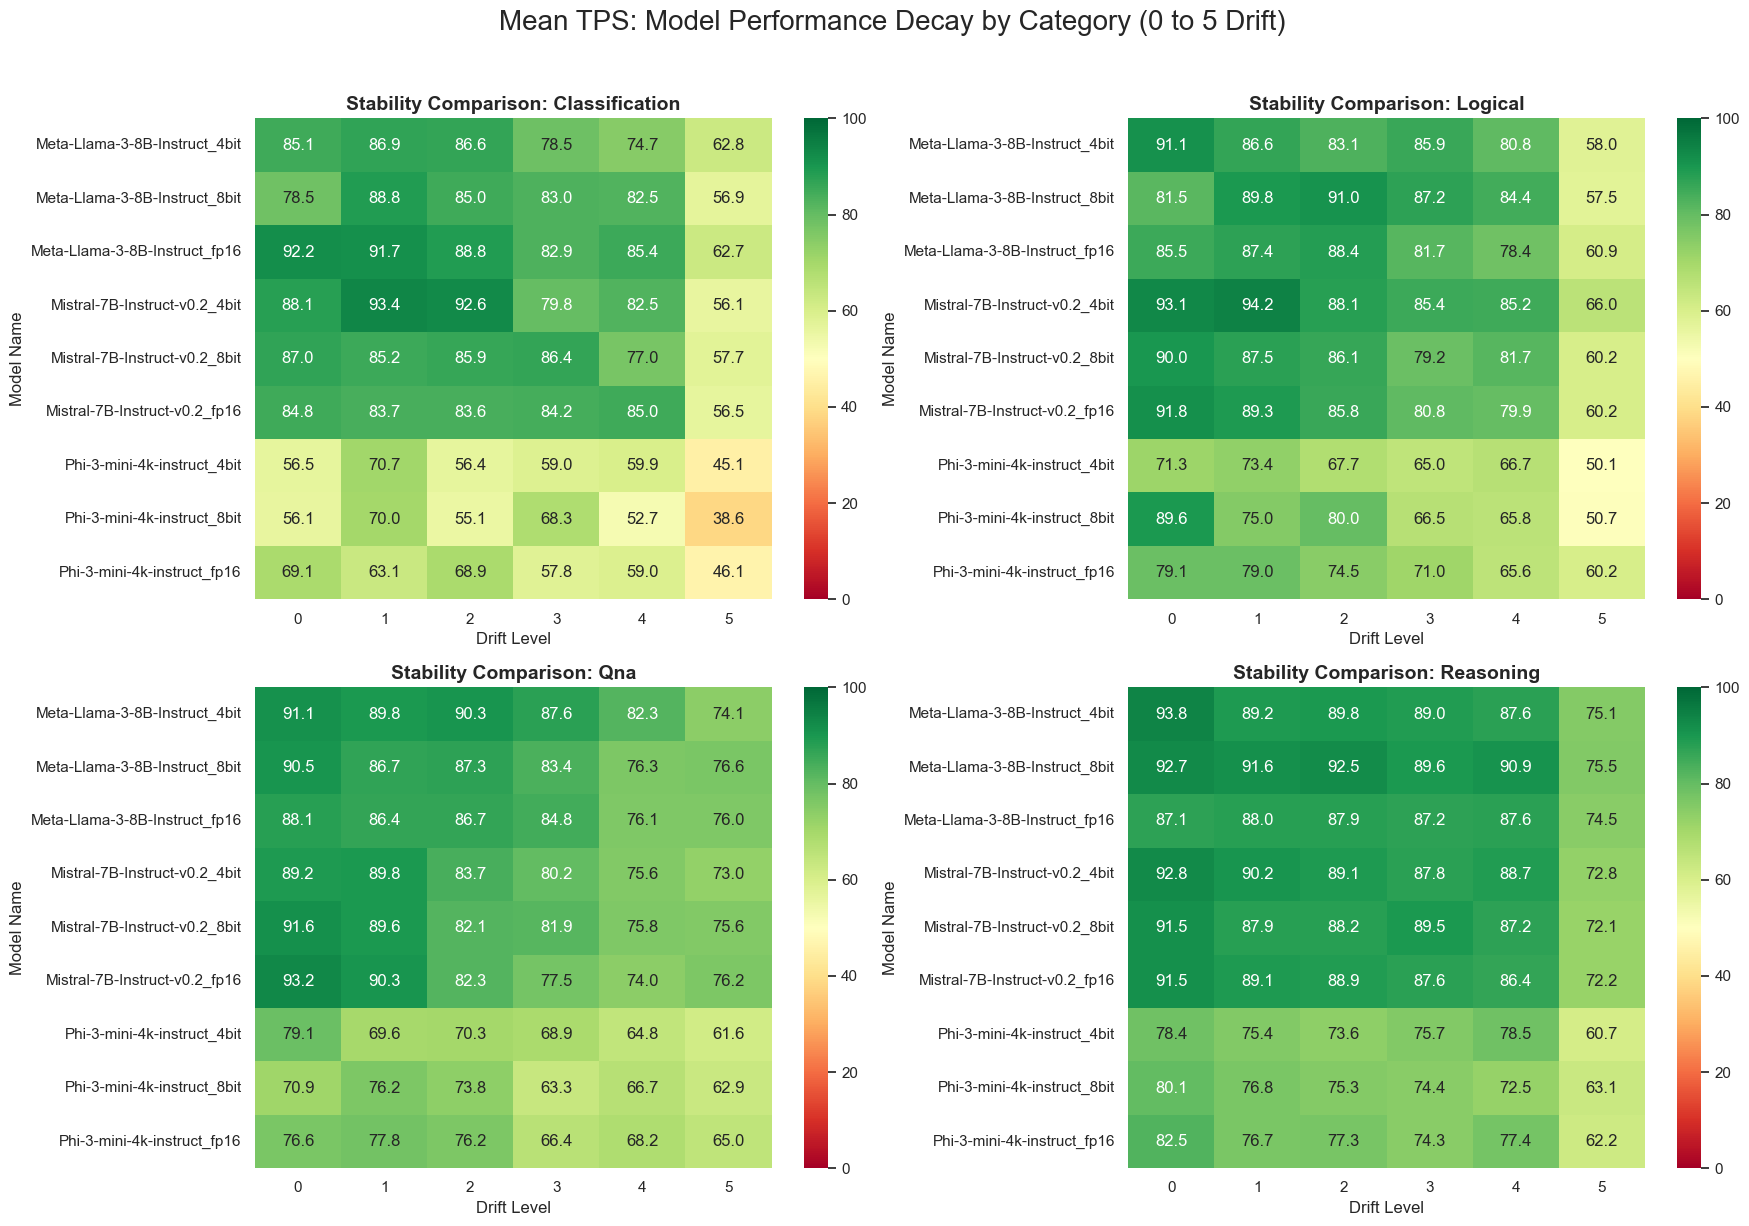

In [109]:
def plot_category_drift_heatmaps(base_tps_dir):
    """
    Generates a 2x2 grid of heatmaps (one per category).
    X-axis: Drift Level (0-5)
    Y-axis: Model Name
    Value: Average TPS of all 10 prompts.
    """
    base_path = Path(base_tps_dir)
    all_data = []

    # 1. Collect all model data
    for json_file in base_path.glob("**/tps_scores_structured.json"):
        model_name = json_file.parent.name
        with open(json_file, 'r') as f:
            data = json.load(f)
            
        for entry in data:
            drift_lvl = entry.get("Drift_Level")
            for key, value in entry.items():
                if key == "Drift_Level" or value is None:
                    continue
                
                # Parse Category from "Prompt X (Category)"
                category = key.split(" (")[1].replace(")", "")
                
                # Average variants (V1, V2, V3) or take single value (V0)
                if isinstance(value, dict):
                    valid_vals = [v for v in value.values() if v is not None]
                    avg_score = sum(valid_vals) / len(valid_vals) if valid_vals else 0
                else:
                    avg_score = value
                
                all_data.append({
                    "Model": model_name,
                    "Drift": drift_lvl,
                    "Category": category,
                    "Score": avg_score
                })

    df_all = pd.DataFrame(all_data)
    if df_all.empty:
        print("No data found for heatmaps.")
        return

    # 2. Setup 2x2 Grid
    categories = sorted(df_all['Category'].unique())
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()

    for i, cat in enumerate(categories):
        subset = df_all[df_all['Category'] == cat]
        
        # Pivot: X = Drift Level, Y = Model, Value = Average TPS
        pivot_df = subset.pivot_table(index="Model", columns="Drift", values="Score", aggfunc='mean')
        
        sns.heatmap(pivot_df, annot=True, cmap="RdYlGn", vmin=0, vmax=100, fmt=".1f", ax=axes[i])
        axes[i].set_title(f"Stability Comparison: {cat.capitalize()}", fontweight='bold', fontsize=14)
        axes[i].set_xlabel("Drift Level")
        axes[i].set_ylabel("Model Name")

    plt.suptitle("Mean TPS: Model Performance Decay by Category (0 to 5 Drift)", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the category-drift comparison
plot_category_drift_heatmaps(r"../5_TPS_calculation/TPS")